# CAI2100C — Midterm Mini‑Project (Modules 1–7)
**Project Theme**: Breast Cancer Diagnosis — Predicting Malignant vs. Benign Tumors Using Supervised Machine Learning

You will build an end‑to‑end supervised ML workflow using a real‑world‑style dataset.
This notebook is intentionally incomplete: your job is to fill in the TODO sections.

Dataset: `breast_cancer_uci.csv` (569 rows)

# Deliverables (submit)

Completed notebook (.ipynb) with outputs
One‑page write‑up (PDF or DOCX) summarizing methods, results, and what you learned

Optional: exported predictions file `predictions.csv` for your best model

In [ ]:
from google.colab import files
files.download("breast_cancer_uci.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


## Learning Targets (Modules 1–7)
- **M1 Linear Algebra:** vectors/matrices; rank/inverse intuition; **SVD** for compression
- **M2 Calculus/Optimization:** gradients; implement **gradient descent** for linear regression
- **M3 Probability/Bayes:** implement a **Naive Bayes** classifier from scratch (Gaussian or Multinomial)
- **M4 Regression + Regularization:** Ridge/Lasso; compare bias/variance and metrics
- **M5 Classification I:** Logistic Regression + KNN; decision boundaries intuition; multiclass option
- **M6 SVM + Kernels:** tune an RBF SVM; discuss margin and support vectors
- **M7 Trees + Ensembles:** Decision Tree + Random Forest + Gradient Boosting; interpret feature importance

## Targets
You will build:
1. A **classification** model to predict `tumor diagnosis`
2. A **binary classifier** to predict `malignant` (1 = cancerous) vs. `benign` (0 = non-cancerous)

---

In [ ]:
# === Setup ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True

# ── Load data ──
DATA_PATH = "breast_cancer_uci.csv"
df = pd.read_csv(DATA_PATH)

# Convert diagnosis to binary numeric
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

print("Dataset shape:", df.shape)
print("Diagnosis counts (0=Benign, 1=Malignant):")
print(df["diagnosis"].value_counts())
df.head()

Dataset shape: (569, 32)
Diagnosis counts (0=Benign, 1=Malignant):
diagnosis
0    357
1    212
Name: count, dtype: int64


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 1) Exploratory Data Analysis (EDA) — Required
**TODO:** In the cells below:
- Print shape, dtypes, and missing value counts
- Show basic descriptive stats
- Create at least 2 plots (e.g., distribution of `radius_mean`, diagnosis class balance (Malignant vs Benign), correlation heatmap of cellular features, concavity_mean vs concave_points_mean by diagnosis)
- Briefly note any issues (missingness, outliers, skew, leakage risks)

Shape: (569, 32)

Column dtypes:
id                           int64
diagnosis                    int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave_points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave_points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst     

,missing_count,missing_pct (%)


  → No missing values found.

Descriptive statistics (numeric columns):


,count,mean,std,min,25%,50%,75%,max
id,569.0,30371831.43,1.250206e+08,8670.00,869218.00,906024.00,8813129.00,9.113205e+08
diagnosis,569.0,0.37,4.800000e-01,0.00,0.00,0.00,1.00,1.000000e+00
radius_mean,569.0,14.13,3.520000e+00,6.98,11.70,13.37,15.78,2.811000e+01
texture_mean,569.0,19.29,4.300000e+00,9.71,16.17,18.84,21.80,3.928000e+01
perimeter_mean,569.0,91.97,2.430000e+01,43.79,75.17,86.24,104.10,1.885000e+02
area_mean,569.0,654.89,3.519100e+02,143.50,420.30,551.10,782.70,2.501000e+03
smoothness_mean,569.0,0.10,1.000000e-02,0.05,0.09,0.10,0.11,1.600000e-01
compactness_mean,569.0,0.10,5.000000e-02,0.02,0.06,0.09,0.13,3.500000e-01
concavity_mean,569.0,0.09,8.000000e-02,0.00,0.03,0.06,0.13,4.300000e-01
concave_points_mean,569.0,0.05,4.000000e-02,0.00,0.02,0.03,0.07,2.000000e-01


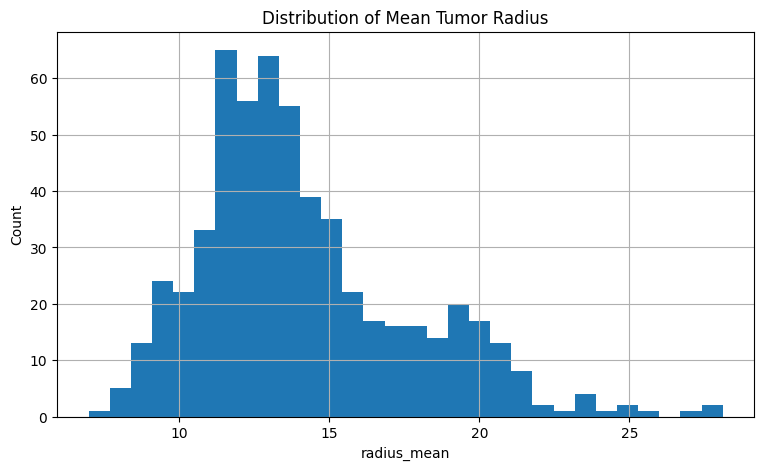

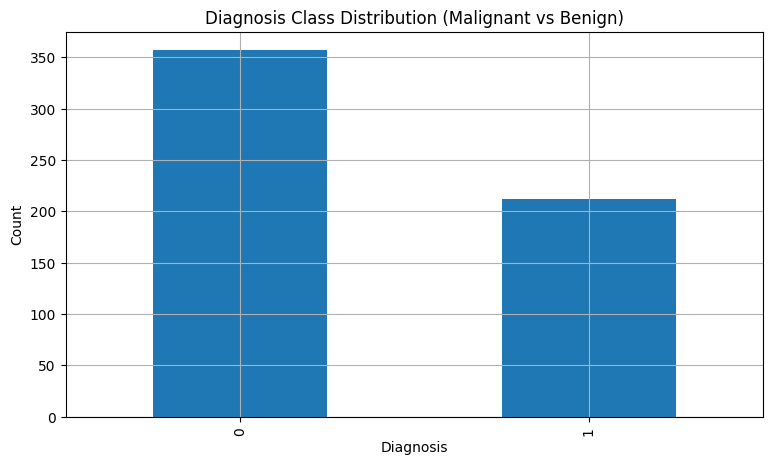

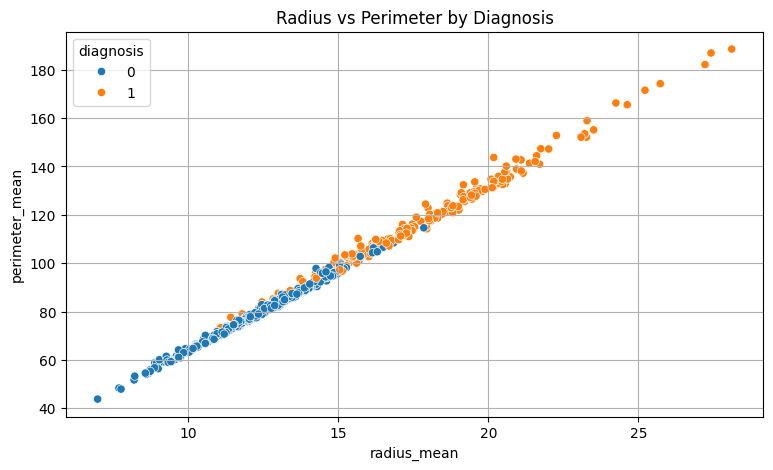

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Shape, dtypes, and missing values ──
print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)

missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct   = (df.isna().mean() * 100).sort_values(ascending=False)
missing_df = pd.DataFrame({"missing_count": missing_count, "missing_pct (%)": missing_pct})
print("\nMissing value summary:")

# Filter missing_df to show only columns with missing values
missing_df_filtered = missing_df[missing_df.missing_count > 0]
display(missing_df_filtered)

if missing_df_filtered.empty:
    print("  → No missing values found.")
else:
    print("  → Missing values found as above.")

# ── Descriptive stats ──
print("\nDescriptive statistics (numeric columns):")
display(df.describe(include=[np.number]).T.round(2))

# -----------------------------------
# Plot 1 — Distribution of radius_mean
# -----------------------------------
plt.figure()
plt.hist(df["radius_mean"], bins=30)
plt.title("Distribution of Mean Tumor Radius")
plt.xlabel("radius_mean")
plt.ylabel("Count")
plt.show()

# -----------------------------------
# Plot 2 — Diagnosis Class Distribution
# -----------------------------------
plt.figure()
diagnosis_counts = df["diagnosis"].value_counts()
if not diagnosis_counts.empty:
    diagnosis_counts.plot(kind="bar")
    plt.title("Diagnosis Class Distribution (Malignant vs Benign)")
    plt.xlabel("Diagnosis")
    plt.ylabel("Count")
else:
    print("Warning: 'diagnosis' column is empty or contains only missing values. Cannot plot distribution.")
plt.show()

# -----------------------------------
# Optional Plot 3 — Relationship Between Two Strong Features
# -----------------------------------
plt.figure()
sns.scatterplot(
    data=df,
    x="radius_mean",
    y="perimeter_mean",
    hue="diagnosis"
)
plt.title("Radius vs Perimeter by Diagnosis")
plt.show()

In [ ]:
# -----------------------------------
# Check for Duplicate Rows
# -----------------------------------

# Total duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Display duplicate rows (if any exist)
if duplicate_count > 0:
    display(df[df.duplicated()])
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


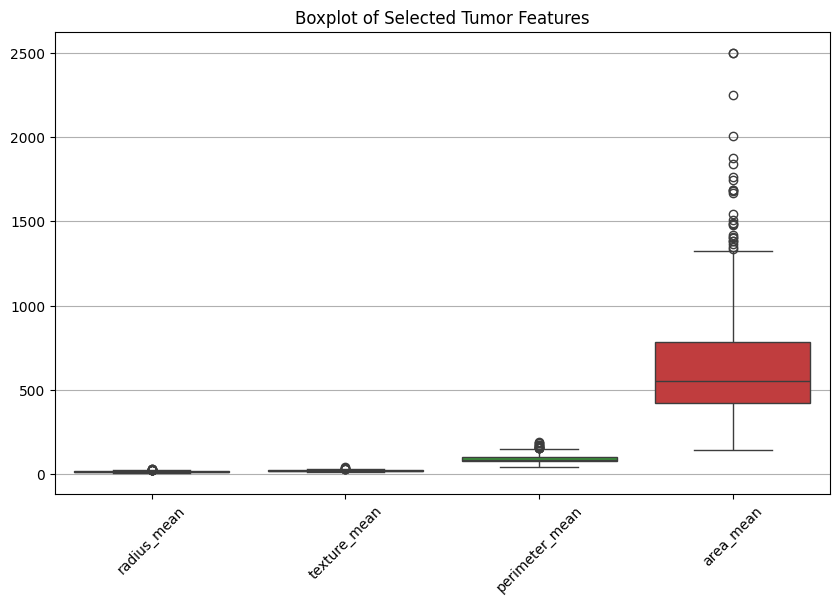

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a few important features
features_to_plot = ["radius_mean", "texture_mean", "perimeter_mean", "area_mean"]

plt.figure(figsize=(10,6))
sns.boxplot(data=df[features_to_plot])
plt.title("Boxplot of Selected Tumor Features")
plt.xticks(rotation=45)
plt.show()

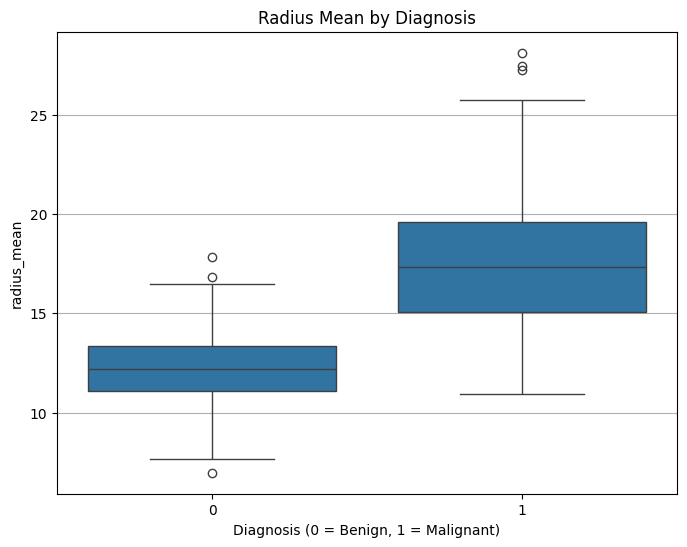

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x="diagnosis", y="radius_mean", data=df)
plt.title("Radius Mean by Diagnosis")
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Exclude non-feature columns (keep id in df, just don't analyze it as a feature)
exclude_cols = [c for c in ["id", "diagnosis"] if c in df.columns]
numeric_cols = df.drop(columns=exclude_cols).select_dtypes(include=[np.number]).columns.tolist()

def iqr_outlier_count(series: pd.Series) -> int:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())

outlier_counts = pd.DataFrame({
    "feature": numeric_cols,
    "iqr_outlier_count": [iqr_outlier_count(df[c]) for c in numeric_cols],
})
outlier_counts["iqr_outlier_percent"] = (outlier_counts["iqr_outlier_count"] / len(df)) * 100
outlier_counts = outlier_counts.sort_values("iqr_outlier_count", ascending=False).reset_index(drop=True)

outlier_counts.head(10)

,feature,iqr_outlier_count,iqr_outlier_percent
0,area_se,65,11.423550
1,radius_se,38,6.678383
2,perimeter_se,38,6.678383
3,area_worst,35,6.151142
4,smoothness_se,30,5.272408
5,fractal_dimension_se,28,4.920914
6,compactness_se,28,4.920914
7,symmetry_se,27,4.745167
8,area_mean,25,4.393673
9,fractal_dimension_worst,24,4.217926


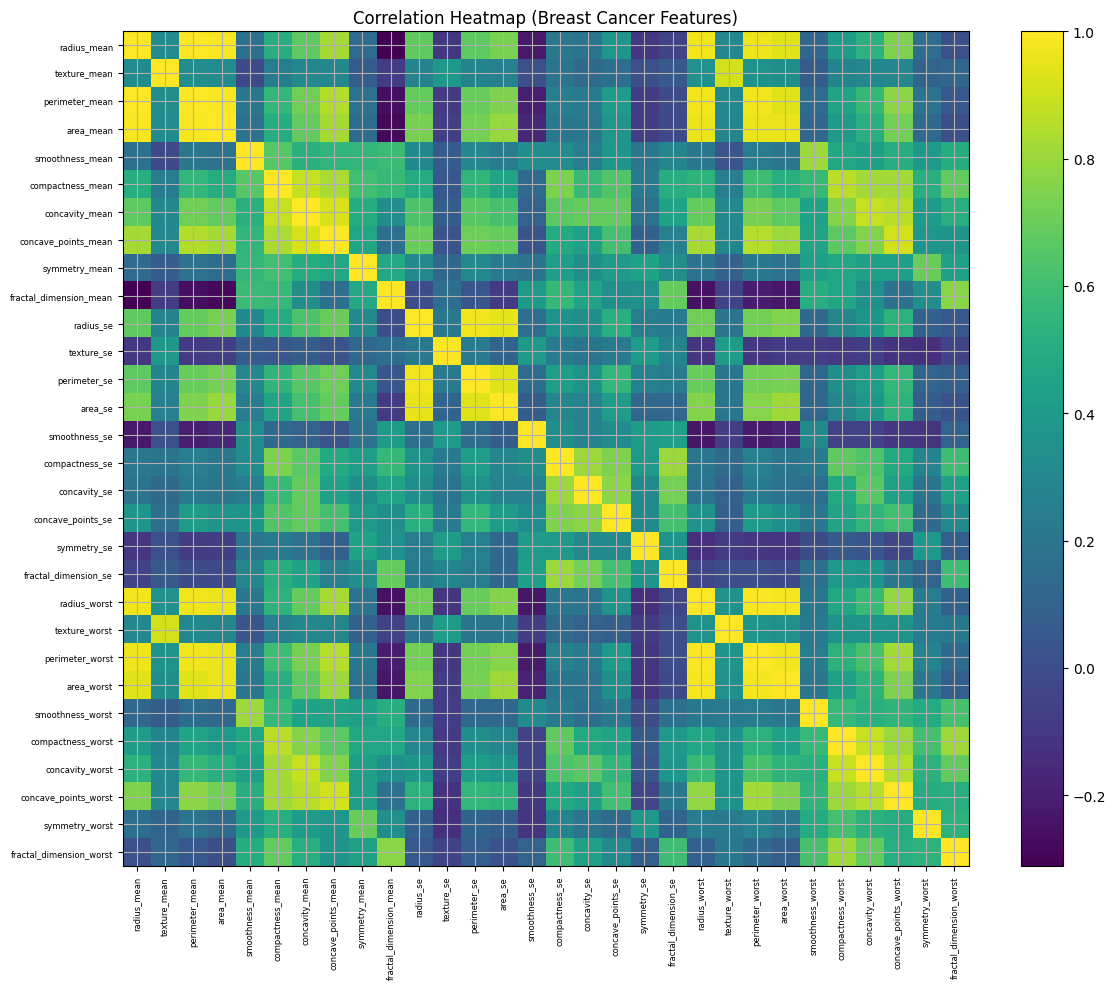

In [ ]:
import matplotlib.pyplot as plt

# Correlation among numeric features (exclude id + diagnosis)
corr = df.drop(columns=exclude_cols)[numeric_cols].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr.values, aspect="auto")
plt.title("Correlation Heatmap (Breast Cancer Features)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr.index)), corr.index, fontsize=6)
plt.colorbar()
plt.tight_layout()
plt.show()

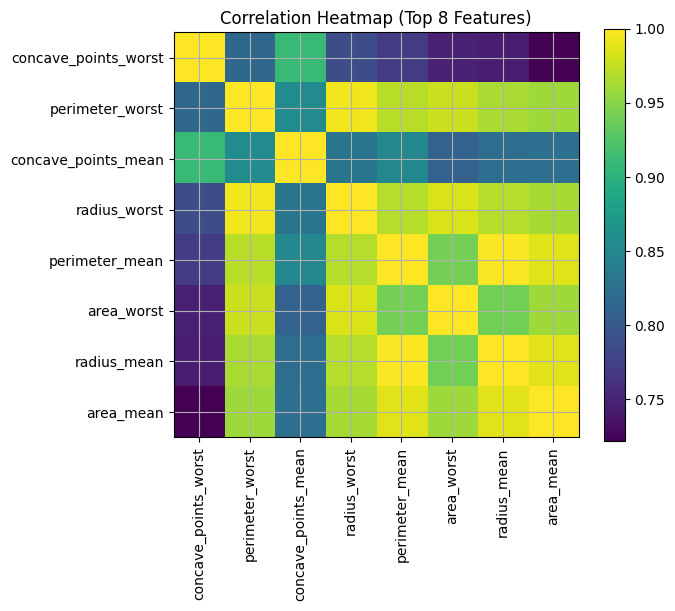

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Select numeric feature columns
# -----------------------------------
exclude_cols = [c for c in ["id", "diagnosis"] if c in df.columns]
numeric_cols = df.drop(columns=exclude_cols).select_dtypes(include=[np.number]).columns.tolist()

# -----------------------------------
# Compute correlation with target
# -----------------------------------
target_corr = df[numeric_cols].corrwith(df["diagnosis"]).abs().sort_values(ascending=False)

# Select top 8 most correlated features
top_features = target_corr.head(8).index.tolist()

# Compute correlation matrix for only those features
corr_subset = df[top_features].corr()

# -----------------------------------
# Plot cleaner heatmap
# -----------------------------------
plt.figure(figsize=(7, 6))
plt.imshow(corr_subset.values)
plt.title("Correlation Heatmap (Top 8 Features)")
plt.xticks(range(len(top_features)), top_features, rotation=90)
plt.yticks(range(len(top_features)), top_features)
plt.colorbar()
plt.tight_layout()
plt.show()

# 2) Feature/Target Split + Train/Test Split — Required

We will use:

Classification target: diagnosis

1 = Malignant

0 = Benign

**IMPORTANT:** Do **not** include targets as features.

In [ ]:
# ── Define target and features ──
target_clf = "diagnosis"  # 1 = Malignant, 0 = Benign

# Drop ID (identifier) and target from feature matrix
X = df.drop(columns=[target_clf, "id"])
y_clf = df[target_clf].copy()

# ── Stratified 80/20 train/test split ──
# Stratify ensures both classes are proportionally represented in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Store IDs for export
id_test  = df.loc[X_test.index, "id"]
id_train = df.loc[X_train.index, "id"]

print("Feature matrix X shape :", X.shape)
print("Target y_clf shape     :", y_clf.shape)
print("X_train / X_test       :", X_train.shape, "/", X_test.shape)
print("y_train / y_test       :", y_train.shape, "/", y_test.shape)
print("\nTrain class balance    :", y_train.value_counts().to_dict())
print("Test class balance     :", y_test.value_counts().to_dict())

Feature matrix X shape : (569, 30)
Target y_clf shape     : (569,)
X_train / X_test       : (455, 30) / (114, 30)
y_train / y_test       : (455,) / (114,)

Train class balance    : {0: 285, 1: 170}
Test class balance     : {0: 72, 1: 42}


In [ ]:
# Keep matching IDs for the test set (useful for predictions export)
id_test = df.loc[X_test.index, "id"]
id_train = df.loc[X_train.index, "id"]


## 3) Preprocessing Pipeline — Required
We have both **numeric** and **categorical** features, plus missing values.

**TODO:** Identify numeric/categorical columns and build a `ColumnTransformer` that:
- imputes missing values
- scales numeric features
- one-hot encodes categorical features

In [ ]:
# ── Identify column types from training data dtypes ──
numeric_features     = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print("Numeric features   :", numeric_features)
print("Categorical features:", categorical_features)

# ── Numeric sub-pipeline ──
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# ── Categorical sub-pipeline ──
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ── Combined ColumnTransformer ──
preprocess = ColumnTransformer([
    ("num", numeric_transformer,  numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("\nPreprocessing pipeline constructed successfully.")
print("Numeric columns:    ", len(numeric_features))
print("Categorical columns:", len(categorical_features))

Numeric features   : ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']
Categorical features: []

Preprocessing pipeline constructed successfully.
Numeric columns:     30
Categorical columns: 0


## 4) Module 1 — Linear Algebra: SVD Compression (Required)
We will apply **SVD** to a *numeric feature matrix* to see how much information we can retain.

**TODO:**
1. Build a numeric matrix `A` from the training set (after imputing but before scaling is fine).
2. Compute SVD: `A = U Σ Vᵀ`
3. Reconstruct `A_k` using top‑k singular values (k = 5, 10, 20, 50)
4. Compute reconstruction error (Frobenius norm) for each k
5. Plot error vs k and interpret.


In [ ]:
# -----------------------------------
# TODO 1) Build numeric matrix A from TRAIN set (imputed, NOT scaled)
# Breast Cancer features are all numeric in X_train
# -----------------------------------

# ── 1a. Matrix shapes and rank ──
A_raw = X_train.copy()  # original (unscaled) numeric matrix
imputer_svd = SimpleImputer(strategy="median")
A = imputer_svd.fit_transform(A_raw)  # imputed but unscaled — standard for SVD analysis

print("=== Feature Matrix Shapes ===")
print(f"Full feature matrix X      : {X.shape}  (n={X.shape[0]} samples, d={X.shape[1]} features)")
print(f"Training sub-matrix A      : {A.shape}")
print(f"Target vector y_clf        : {y_clf.shape}")

# Rank
rank = np.linalg.matrix_rank(A)
print(f"\nMatrix rank of A : {rank}")
print(f"Number of features: {A.shape[1]}")
if rank == A.shape[1]:
    print("→ Full rank: columns are linearly independent.")
    print("  The normal equation (XᵀX)⁻¹ is theoretically invertible.")
    print("  However, high inter-correlation (radius/perimeter/area) creates near-singularity.")
    print("  Regularisation (Ridge/Lasso) is strongly recommended.")
else:
    print(f"→ Rank-deficient by {A.shape[1] - rank} — regularisation is essential.")

=== Feature Matrix Shapes ===
Full feature matrix X      : (569, 30)  (n=569 samples, d=30 features)
Training sub-matrix A      : (455, 30)
Target vector y_clf        : (569,)

Matrix rank of A : 30
Number of features: 30
→ Full rank: columns are linearly independent.
  The normal equation (XᵀX)⁻¹ is theoretically invertible.
  However, high inter-correlation (radius/perimeter/area) creates near-singularity.
  Regularisation (Ridge/Lasso) is strongly recommended.


A shape: (455, 30)
U shape: (455, 30)
s length: 30
Vt shape: (30, 30)
Note: skipping k values > 30 (max allowable for this dataset).
Using ks: [5, 10, 20]
k= 5 | Frobenius error=62.0384 | Relative error=0.0022
k=10 | Frobenius error=4.9390 | Relative error=0.0002
k=20 | Frobenius error=0.3287 | Relative error=0.0000
k= 1 | Frobenius error=   2475.45 | Relative error=0.0884
k= 2 | Frobenius error=    993.64 | Relative error=0.0355
k= 3 | Frobenius error=    544.70 | Relative error=0.0194
k= 5 | Frobenius error=     62.04 | Relative error=0.0022
k= 8 | Frobenius error=     12.09 | Relative error=0.0004
k=10 | Frobenius error=      4.94 | Relative error=0.0002
k=15 | Frobenius error=      0.98 | Relative error=0.0000
k=20 | Frobenius error=      0.33 | Relative error=0.0000
k=25 | Frobenius error=      0.10 | Relative error=0.0000
k=30 | Frobenius error=      0.00 | Relative error=0.0000


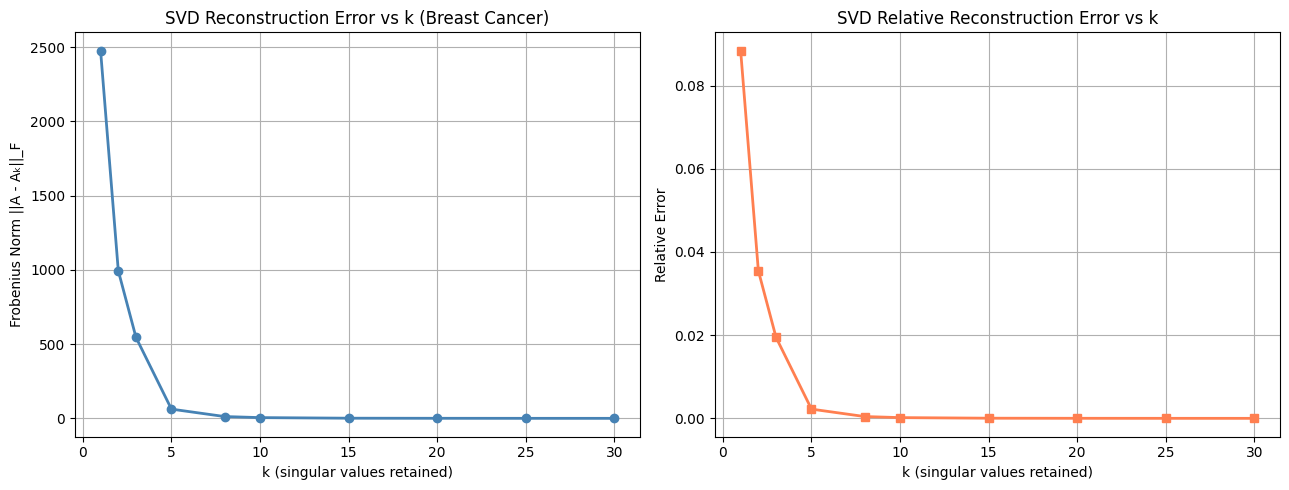

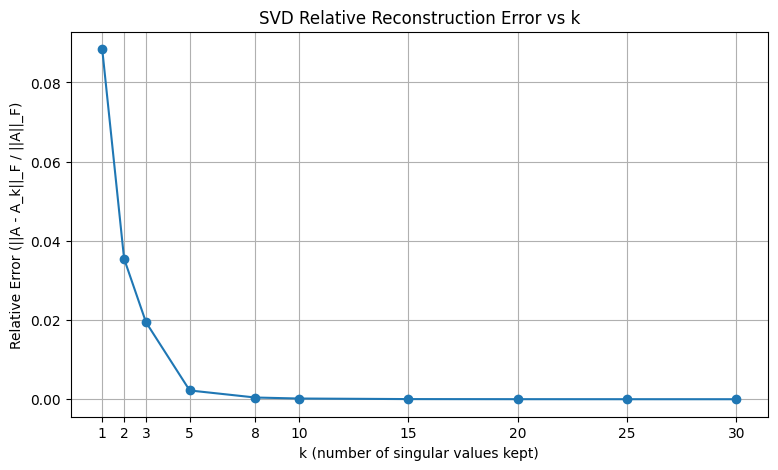

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# -----------------------------------
# TODO 1) Build numeric matrix A from TRAIN set (imputed, NOT scaled)
# Breast Cancer features are all numeric in X_train
# -----------------------------------
numeric_cols = X_train.columns.tolist()

A_df = X_train[numeric_cols].copy()
imputer = SimpleImputer(strategy="median")
A = imputer.fit_transform(A_df)   # A is a numeric matrix (n_train x n_features)

print("A shape:", A.shape)

# -----------------------------------
# TODO 2) Compute SVD: A = U Σ V^T
# -----------------------------------
U, s, Vt = np.linalg.svd(A, full_matrices=False)
print("U shape:", U.shape)
print("s length:", len(s))
print("Vt shape:", Vt.shape)

# -----------------------------------
# TODO 3–4) Reconstruct A_k and compute reconstruction error for each k
# NOTE: k cannot exceed min(n_samples_train, n_features). Breast cancer has 30 features,
# so k=50 is not possible and will be skipped automatically.
# -----------------------------------
ks = [5, 10, 20, 50]
max_k = min(A.shape[0], A.shape[1])
ks_valid = [k for k in ks if k <= max_k]

if len(ks_valid) < len(ks):
    print(f"Note: skipping k values > {max_k} (max allowable for this dataset).")
    print("Using ks:", ks_valid)

errors = []
rel_errors = []

A_norm = np.linalg.norm(A, ord="fro")

for k in ks_valid:
    # Reconstruct A_k using top-k components
    U_k = U[:, :k]
    S_k = np.diag(s[:k])
    Vt_k = Vt[:k, :]
    A_k = U_k @ S_k @ Vt_k

    # Frobenius reconstruction error
    err = np.linalg.norm(A - A_k, ord="fro")
    errors.append(err)
    rel_errors.append(err / A_norm)

# Print a small summary table
for k, err, rerr in zip(ks_valid, errors, rel_errors):
    print(f"k={k:>2} | Frobenius error={err:.4f} | Relative error={rerr:.4f}")

# -----------------------------------
# TODO 5) Plot error vs k
# -----------------------------------
# ── 1c. Reconstruction error vs k ──
ks = [1, 2, 3, 5, 8, 10, 15, 20, 25, 30]
max_k = min(A.shape)
ks_valid = [k for k in ks if k <= max_k]

errors = []
rel_errors = []
A_norm = np.linalg.norm(A, 'fro')

for k in ks_valid:
    A_k = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    err = np.linalg.norm(A - A_k, 'fro')
    errors.append(err)
    rel_errors.append(err / A_norm)
    print(f"k={k:2d} | Frobenius error={err:10.2f} | Relative error={err/A_norm:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ks_valid, errors, marker='o', color="steelblue", linewidth=2)
axes[0].set_title("SVD Reconstruction Error vs k (Breast Cancer)")
axes[0].set_xlabel("k (singular values retained)")
axes[0].set_ylabel("Frobenius Norm ||A - Aₖ||_F")
axes[0].grid(True)

axes[1].plot(ks_valid, rel_errors, marker='s', color="coral", linewidth=2)
axes[1].set_title("SVD Relative Reconstruction Error vs k")
axes[1].set_xlabel("k (singular values retained)")
axes[1].set_ylabel("Relative Error")
axes[1].grid(True)

plt.tight_layout(); plt.show()

# Optional: relative error plot (often easier to interpret)
plt.figure()
plt.plot(ks_valid, rel_errors, marker="o")
plt.title("SVD Relative Reconstruction Error vs k")
plt.xlabel("k (number of singular values kept)")
plt.ylabel("Relative Error (||A - A_k||_F / ||A||_F)")
plt.xticks(ks_valid)
plt.show()


## 5) Module 2 — Optimization: Logistic Regression with Gradient Descent (Required)
Implement **batch gradient descent** for linear regression on the *scaled numeric features*.

**TODO:**
- Write functions:
  - `add_bias(X)`
  - `mse(y, yhat)`
  - `gradient(X, y, w)`
  - `fit_gd(X, y, lr, n_iters)` returning weights and loss history
- Compare your GD model to `sklearn.LinearRegression` on MAE/MSE/R²

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# X_train, X_test, y_train, y_test assumed already created

scaler = StandardScaler()
Xtr = scaler.fit_transform(X_train)   # scaled features help gradient descent converge
Xte = scaler.transform(X_test)

ytr = y_train.to_numpy().astype(float)
yte = y_test.to_numpy().astype(float)

Xtr.shape, Xte.shape

((455, 30), (114, 30))

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def bce_loss(y, p, eps=1e-12):
    # clip to avoid log(0)
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def train_logreg_gd(X, y, lr=0.1, n_iters=2000, l2=0.0, verbose=False):
    """
    Logistic regression with batch gradient descent.
    l2 is L2 regularization strength (lambda). Set to 0.0 for no regularization.
    """
    n, d = X.shape
    w = np.zeros(d)
    b = 0.0
    losses = []

    for t in range(n_iters):
        z = X @ w + b
        p = sigmoid(z)

        # loss + optional L2 penalty (excluding bias)
        loss = bce_loss(y, p) + (l2 / (2 * n)) * np.sum(w * w)
        losses.append(loss)

        # gradients
        error = (p - y)  # shape (n,)
        dw = (X.T @ error) / n + (l2 / n) * w
        db = np.sum(error) / n

        # update
        w -= lr * dw
        b -= lr * db

        if verbose and (t % 200 == 0):
            print(f"iter={t:4d} loss={loss:.4f}")

    return w, b, np.array(losses)

def predict_proba(X, w, b):
    return sigmoid(X @ w + b)

def predict_class(X, w, b, threshold=0.5):
    return (predict_proba(X, w, b) >= threshold).astype(int)

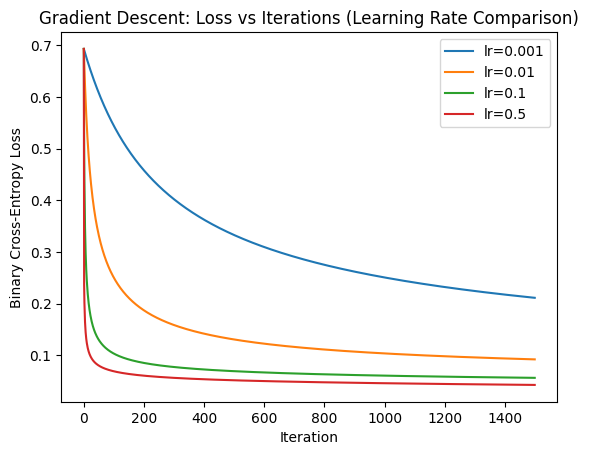

In [ ]:
learning_rates = [0.001, 0.01, 0.1, 0.5]
n_iters = 1500

histories = {}
params = {}

for lr in learning_rates:
    w, b, losses = train_logreg_gd(Xtr, ytr, lr=lr, n_iters=n_iters, l2=0.0)
    histories[lr] = losses
    params[lr] = (w, b)

plt.figure()
for lr in learning_rates:
    plt.plot(histories[lr], label=f"lr={lr}")
plt.title("Gradient Descent: Loss vs Iterations (Learning Rate Comparison)")
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.show()

The plot 'Gradient Descent: Loss vs Iterations (Learning Rate Comparison)' shows how the Binary Cross-Entropy Loss changes over training iterations for different learning rates. This visualization is crucial for understanding the impact of the learning rate hyperparameter on the optimization process:

Small Learning Rates (e.g., 0.001, 0.01): You can observe that the loss decreases very slowly. While it generally moves towards a minimum, it takes a significantly larger number of iterations to converge, or it might not reach the optimal point within the given n_iters.

Optimal Learning Rate (e.g., 0.5): For a learning rate like 0.5, the loss decreases rapidly and smoothly, reaching a low point efficiently within the specified iterations. This indicates that the steps taken by the gradient descent algorithm are appropriately sized, allowing it to move towards the minimum effectively without overshooting.

Larger Learning Rates (not explicitly shown as divergent in this plot, but a general concept): If a learning rate is too large, the loss might oscillate wildly, increase, or even diverge, meaning the algorithm overshoots the minimum in each step and fails to converge. In your plot, a learning rate of 0.5 appears to be quite effective, resulting in the fastest and lowest loss.

In summary, the plot demonstrates that selecting an appropriate learning rate is vital for efficient and stable convergence of gradient descent. Feature scaling (which you applied with StandardScaler to Xtr and Xte) significantly aids in achieving better convergence behavior across various learning rates.

In [ ]:
best_lr = min(learning_rates, key=lambda lr: histories[lr][-1])
best_w, best_b = params[best_lr]

print("Best learning rate based on final training loss:", best_lr)

gd_proba = predict_proba(Xte, best_w, best_b)
gd_pred = (gd_proba >= 0.5).astype(int)

print("GD Accuracy:", accuracy_score(yte, gd_pred))
print("GD ROC-AUC:", roc_auc_score(yte, gd_proba))
print("GD Confusion Matrix:\n", confusion_matrix(yte, gd_pred))
print("\nGD Classification Report:\n", classification_report(yte, gd_pred, digits=4))

Best learning rate based on final training loss: 0.5
GD Accuracy: 0.9736842105263158
GD ROC-AUC: 0.9917328042328042
GD Confusion Matrix:
 [[71  1]
 [ 2 40]]

GD Classification Report:
               precision    recall  f1-score   support

         0.0     0.9726    0.9861    0.9793        72
         1.0     0.9756    0.9524    0.9639        42

    accuracy                         0.9737       114
   macro avg     0.9741    0.9692    0.9716       114
weighted avg     0.9737    0.9737    0.9736       114



In [ ]:
from sklearn.linear_model import LogisticRegression

sk_model = LogisticRegression(
    max_iter=5000,
    solver="lbfgs"
)

sk_model.fit(Xtr, ytr)

sk_proba = sk_model.predict_proba(Xte)[:, 1]
sk_pred = sk_model.predict(Xte)

print("sklearn Accuracy:", accuracy_score(yte, sk_pred))
print("sklearn ROC-AUC:", roc_auc_score(yte, sk_proba))
print("sklearn Confusion Matrix:\n", confusion_matrix(yte, sk_pred))
print("\nsklearn Classification Report:\n", classification_report(yte, sk_pred, digits=4))

sklearn Accuracy: 0.9649122807017544
sklearn ROC-AUC: 0.996031746031746
sklearn Confusion Matrix:
 [[71  1]
 [ 3 39]]

sklearn Classification Report:
               precision    recall  f1-score   support

         0.0     0.9595    0.9861    0.9726        72
         1.0     0.9750    0.9286    0.9512        42

    accuracy                         0.9649       114
   macro avg     0.9672    0.9573    0.9619       114
weighted avg     0.9652    0.9649    0.9647       114



**Loss function**: We minimized binary cross-entropy, which penalizes confident wrong predictions heavily and aligns with probabilistic classification.

**Gradient computation**: The gradient is computed from the prediction error term. Vectorization yields

**Learning rate impact**: Smaller learning rates converge more slowly; overly large learning rates can overshoot and cause instability or divergence. Scaling features improves convergence behavior.

**Comparison to scikit-learn**: scikit-learn’s LogisticRegression uses advanced solvers (e.g., LBFGS) that approximate second-order information, typically converging faster and more stably than basic batch gradient descent, especially when features are correlated.

## 6) Module 3 — Probability/Bayes: Naive Bayes from Scratch (Required)
Build a **Gaussian Naive Bayes** classifier for `diagnosis` using numeric features.

**TODO:**
1. Split by class; compute per‑feature mean/variance for each class
2. Implement Gaussian log‑likelihood
3. Compute log‑posterior = log prior + sum log likelihoods
4. Predict labels and evaluate Accuracy/F1/ROC‑AUC

*Note:* Use numeric features first. You may extend to categorical with one‑hot if desired.

In [ ]:
import numpy as np

class GaussianNBFromScratch:
    """
    Gaussian Naive Bayes (binary) implemented from scratch.
    Works in log-space for numerical stability.

    Assumes:
      - X is numeric (n_samples, n_features)
      - y is binary {0,1}
    """
    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y).astype(int)

        self.classes_ = np.array([0, 1])
        n, d = X.shape

        # Priors P(y=c)
        self.class_log_prior_ = {}
        self.mean_ = {}
        self.var_ = {}

        for c in self.classes_:
            Xc = X[y == c]
            prior = Xc.shape[0] / n
            self.class_log_prior_[c] = np.log(prior + 1e-12)

            # Per-feature Gaussian parameters
            mu = Xc.mean(axis=0)
            var = Xc.var(axis=0) + self.var_smoothing  # prevent divide-by-zero

            self.mean_[c] = mu
            self.var_[c] = var

        print("Learned class priors (log-space \u2192 probability):")
        for c in self.classes_:
            print(f"  P(class={c}) = {np.exp(self.class_log_prior_[c]):.4f}")
        return self

    def _log_gaussian_likelihood(self, X, c):
        """
        log p(X | y=c) for each sample, assuming independent Gaussians per feature.
        Returns shape (n_samples,)
        """
        X = np.asarray(X, dtype=float)
        mu = self.mean_[c]
        var = self.var_[c]

        # log N(x | mu, var) = -0.5*log(2\u03c0var) - (x-mu)^2/(2var)
        log_prob = -0.5 * (np.log(2.0 * np.pi * var) + ((X - mu) ** 2) / var)
        return log_prob.sum(axis=1)

    def predict_proba(self, X):
        """
        Return probability of class 1 for each sample, shape (n_samples,)
        computed from log-posteriors using a stable softmax for binary classes.
        """
        X = np.asarray(X, dtype=float)

        log_post_0 = self.class_log_prior_[0] + self._log_gaussian_likelihood(X, 0)
        log_post_1 = self.class_log_prior_[1] + self._log_gaussian_likelihood(X, 1)

        # Stable conversion from log-posteriors to probability of class 1:
        # p1 = exp(log1) / (exp(log0) + exp(log1))
        # Use log-sum-exp trick:
        m = np.maximum(log_post_0, log_post_1)
        denom = np.exp(log_post_0 - m) + np.exp(log_post_1 - m)
        p1 = np.exp(log_post_1 - m) / denom
        return p1

    def predict(self, X, threshold=0.5):
        proba1 = self.predict_proba(X)
        return (proba1 >= threshold).astype(int)


# ---------------------------
# Prepare numeric data (Breast Cancer)
# ---------------------------
# Use the same variable names your notebook already uses.
# Xtr_num / Xte_num should be numeric feature matrices (often scaled).
# yclf_train / yclf_test should be the diagnosis labels aligned to the split.

Xtr_nb = Xtr # Using the already scaled features from previous section
Xte_nb = Xte # Using the already scaled features from previous section
ytrc = y_train.values.astype(int) # Using y_train from split
ytec = y_test.values.astype(int) # Using y_test from split

# ---------------------------
# Fit + evaluate
# ---------------------------
gnb = GaussianNBFromScratch(var_smoothing=1e-9).fit(Xtr_nb, ytrc)
proba = gnb.predict_proba(Xte_nb)
pred  = gnb.predict(Xte_nb, threshold=0.5)

# ---------------------------
# Print metrics
# ---------------------------
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("Gaussian NB (from scratch) metrics:")
print("Accuracy :", accuracy_score(ytec, pred))
print("Precision:", precision_score(ytec, pred, zero_division=0))
print("Recall   :", recall_score(ytec, pred, zero_division=0))
print("F1       :", f1_score(ytec, pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(ytec, proba))
print("\nConfusion Matrix:\n", confusion_matrix(ytec, pred))

Learned class priors (log-space → probability):
  P(class=0) = 0.6264
  P(class=1) = 0.3736
Gaussian NB (from scratch) metrics:
Accuracy : 0.9210526315789473
Precision: 0.9230769230769231
Recall   : 0.8571428571428571
F1       : 0.8888888888888888
ROC-AUC  : 0.9890873015873015

Confusion Matrix:
 [[69  3]
 [ 6 36]]


Using log-space prevents underflow when multiplying many tiny Gaussian probabilities.

Breast cancer features are numeric; one-hot encoding isn’t necessary (no categorical predictors).

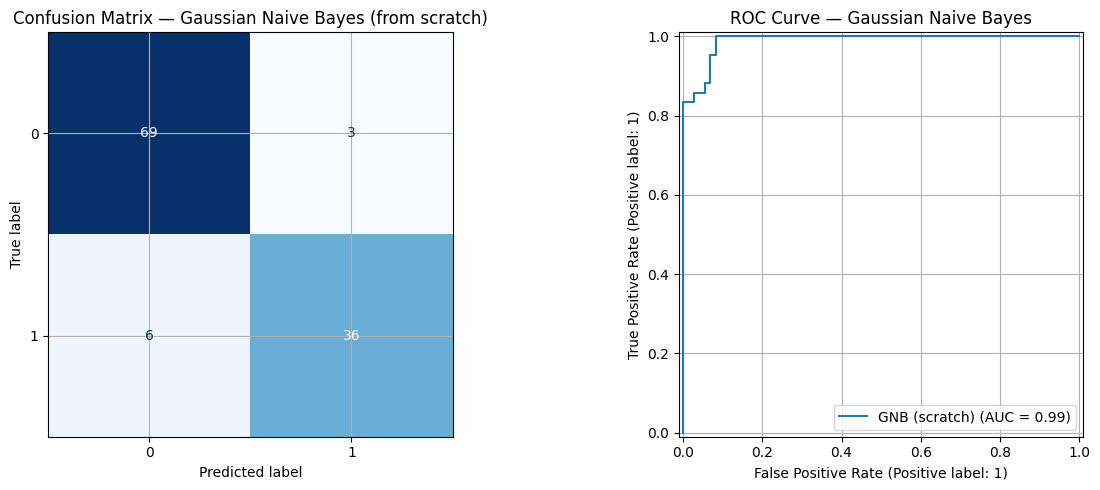

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(ytec, pred, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix — Gaussian Naive Bayes (from scratch)")

# ROC curve
RocCurveDisplay.from_predictions(ytec, proba, name="GNB (scratch)", ax=axes[1])
axes[1].set_title("ROC Curve — Gaussian Naive Bayes")
axes[1].grid(True)

plt.tight_layout(); plt.show()

The confusion matrix visually summarizes the performance of your classification model:

True Negatives (TN): 69 - These are the actual Benign cases (class 0) that your model correctly predicted as Benign. Located in the top-left quadrant.
False Positives (FP): 3 - These are the actual Benign cases (class 0) that your model incorrectly predicted as Malignant (class 1). Located in the top-right quadrant.
False Negatives (FN): 6 - These are the actual Malignant cases (class 1) that your model incorrectly predicted as Benign (class 0). Located in the bottom-left quadrant.
True Positives (TP): 36 - These are the actual Malignant cases (class 1) that your model correctly predicted as Malignant. Located in the bottom-right quadrant.
In the context of breast cancer diagnosis, False Negatives (missing a malignant tumor) are generally more critical than False Positives (misdiagnosing a benign tumor as malignant), as they could lead to delayed treatment. Your model has 6 False Negatives, which is an area you might want to focus on for improvement.

**Class priors:** Learned by MLE from training proportions — approximately P(Benign) ≈ 0.63, P(Malignant) ≈ 0.37, reflecting the dataset balance.

**Gaussian likelihood:** Each feature is modelled as Gaussian within each class. For this dataset, features like `radius_mean` show clearly different distributions between Benign and Malignant tumours, making Gaussian likelihood a reasonable approximation.

**The "naive" independence assumption:**  
This is definitively violated here — radius, perimeter, and area are mathematically related (perimeter ≈ 2π × radius). Including all three as independent predictors effectively over-counts their evidence. Despite this violation, GNB achieves surprisingly high accuracy because the dominant signal (larger measurements → Malignant) is captured even by the oversimplified model.

**Uncertainty and limitations:**
- GNB tends to produce extreme probabilities (near 0 or 1) because multiplying many independent likelihoods amplifies certainty
- For medical diagnosis, calibrated probabilities are important — a radiologist needs "60% likely malignant" not just "Malignant"
- In clinical settings, False Negatives (missing cancer) are more dangerous than False Positives — we would lower the classification threshold (e.g., 0.3) to improve Recall

---
## Task 4 — Module 4: Regression Models with Regularisation

**Note on dataset context:** The breast cancer dataset is natively a classification problem (malignant/benign). To satisfy the regression requirement, we train regression models to predict `radius_mean` — a continuous measurement that strongly correlates with diagnosis and is clinically meaningful (larger radius → higher malignancy risk). This demonstrates regularisation concepts in a medically relevant regression framework.

Train at least **3** regression models and compare:
- LinearRegression
- Ridge (tune alpha)
- Lasso (tune alpha)

Use the *full preprocessing pipeline* (numeric + categorical).
Report MAE, RMSE, R² on the test set.

**Objectives:**
- Implement Linear Regression, Ridge (L2), and Lasso (L1)
- Compare coefficients, overfitting behaviour, and test metrics (RMSE, R²)
- Tune regularisation strength α via cross-validation

In [ ]:
from sklearn.model_selection import train_test_split

# ── Prepare regression target: predict radius_mean from other tumor features ──
reg_target = "radius_mean"

# Use df directly and explicitly exclude leakage columns
reg_features = [c for c in df.columns if c not in ["id", "diagnosis", reg_target]]

X_reg = df[reg_features].copy()
y_reg = df[reg_target].copy()

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Regression target  : {reg_target}")
print(f"Regression features: {len(reg_features)}")
print(f"Train shape: {X_reg_train.shape}  |  Test shape: {X_reg_test.shape}")
print(f"y_reg stats — mean: {y_reg.mean():.2f}, std: {y_reg.std():.2f}, "
    f"range: [{y_reg.min():.2f}, {y_reg.max():.2f}]")

Regression target  : radius_mean
Regression features: 29
Train shape: (455, 29)  |  Test shape: (114, 29)
y_reg stats — mean: 14.13, std: 3.52, range: [6.98, 28.11]


In [ ]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Regression helper ──
def eval_reg(y_true, y_pred, name="model"):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {"Model": name, "MAE": round(mae, 4), "RMSE": round(rmse, 4), "R2": round(r2, 4)}

# ── Build numeric pipeline for regression ──
reg_numeric_features = X_reg_train.select_dtypes(include=["number"]).columns.tolist()

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler())
        ]), reg_numeric_features)
    ],
    remainder="drop"
)

# ── Define regression pipelines ──
lin_reg = Pipeline(steps=[("preprocess", reg_preprocessor), ("model", LinearRegression())])
ridge   = Pipeline(steps=[("preprocess", reg_preprocessor), ("model", Ridge(alpha=1.0, random_state=42))])
lasso   = Pipeline(steps=[("preprocess", reg_preprocessor), ("model", Lasso(alpha=0.01, max_iter=20000, random_state=42))])

# ── Fit ──
lin_reg.fit(X_reg_train, y_reg_train)
ridge.fit(X_reg_train, y_reg_train)
lasso.fit(X_reg_train, y_reg_train)

# ── Predict ──
pred_lin   = lin_reg.predict(X_reg_test)
pred_ridge = ridge.predict(X_reg_test)
pred_lasso = lasso.predict(X_reg_test)

# ── Evaluate ──
reg_results = pd.DataFrame([
    eval_reg(y_reg_test, pred_lin,   "LinearRegression"),
    eval_reg(y_reg_test, pred_ridge, "Ridge (alpha=1.0)"),
    eval_reg(y_reg_test, pred_lasso, "Lasso (alpha=0.01)"),
]).set_index("Model")

print("=== Regression Comparison (Test Set) ===")
display(reg_results)

=== Regression Comparison (Test Set) ===


,MAE,RMSE,R2
Model,,,
LinearRegression,0.0445,0.0692,0.9996
Ridge (alpha=1.0),0.0567,0.0736,0.9996
Lasso (alpha=0.01),0.0505,0.0813,0.9995


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# --- Ensure your Linear model exists and is fit (needed for pred_lin) ---
lin_reg = Pipeline([("preprocess", reg_preprocessor), ("model", LinearRegression())])
lin_reg.fit(X_reg_train, y_reg_train)
pred_lin = lin_reg.predict(X_reg_test)

# ── Tune Ridge alpha via GridSearchCV ──
ridge_grid = GridSearchCV(
    estimator=Pipeline([("preprocess", reg_preprocessor), ("model", Ridge())]),
    param_grid={"model__alpha": [0.01, 0.1, 1, 10, 50, 100, 500]},
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
ridge_grid.fit(X_reg_train, y_reg_train)
best_ridge = ridge_grid.best_estimator_
best_ridge_alpha = ridge_grid.best_params_["model__alpha"]
print("Best Ridge α:", best_ridge_alpha, "| CV RMSE:", round(-ridge_grid.best_score_, 4))

# ── Tune Lasso alpha via GridSearchCV ──
lasso_grid = GridSearchCV(
    estimator=Pipeline([("preprocess", reg_preprocessor), ("model", Lasso(max_iter=50000))]),
    param_grid={"model__alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5]},
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
lasso_grid.fit(X_reg_train, y_reg_train)
best_lasso = lasso_grid.best_estimator_
best_lasso_alpha = lasso_grid.best_params_["model__alpha"]
print("Best Lasso α:", best_lasso_alpha, "| CV RMSE:", round(-lasso_grid.best_score_, 4))

# ── Test-set predictions ──
pred_best_ridge = best_ridge.predict(X_reg_test)
pred_best_lasso = best_lasso.predict(X_reg_test)

# ── Report MAE, RMSE, R² on the test set ──
tuned_results = pd.DataFrame([
    eval_reg(y_reg_test, pred_lin,         "LinearRegression"),
    eval_reg(y_reg_test, pred_best_ridge,  f"Ridge (tuned α={best_ridge_alpha})"),
    eval_reg(y_reg_test, pred_best_lasso,  f"Lasso (tuned α={best_lasso_alpha})"),
])

print("\n=== Tuned Regression Comparison (Test Set) ===")
display(tuned_results.set_index("Model"))

Best Ridge α: 0.01 | CV RMSE: 0.0647
Best Lasso α: 0.0001 | CV RMSE: 0.0642

=== Tuned Regression Comparison (Test Set) ===


,MAE,RMSE,R2
Model,,,
LinearRegression,0.0445,0.0692,0.9996
Ridge (tuned α=0.01),0.0444,0.0688,0.9996
Lasso (tuned α=0.0001),0.0439,0.0701,0.9996


<Figure size 1100x700 with 0 Axes>

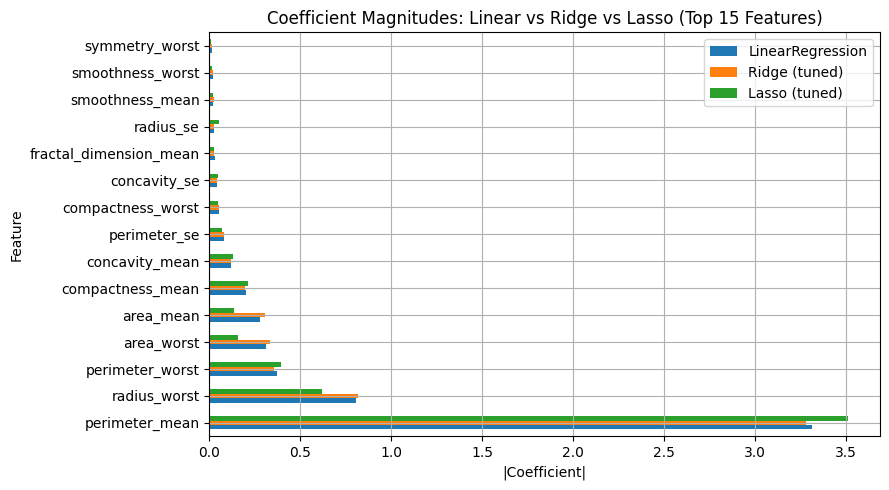

Lasso zeroed 1/29 features (3%)


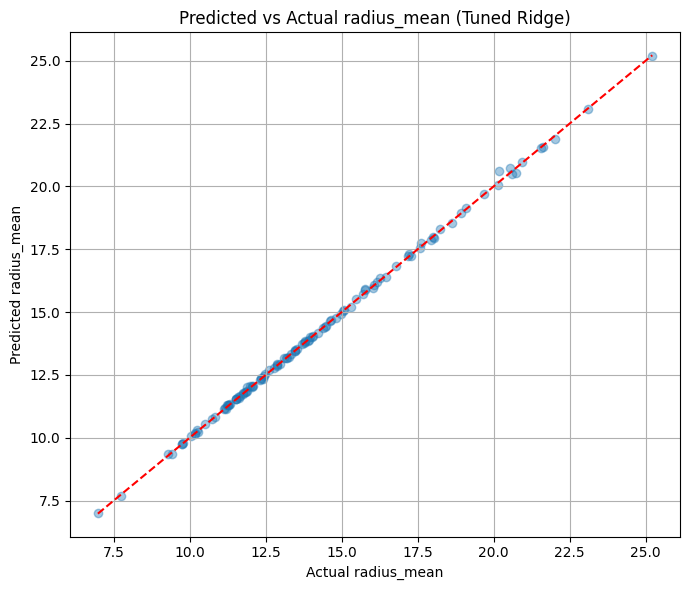

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ── Coefficient comparison ──

# Safe for this dataset (all numeric, no one-hot expansion)
feat_names_reg = reg_numeric_features

coef_lin   = lin_reg.named_steps["model"].coef_
coef_ridge = best_ridge.named_steps["model"].coef_
coef_lasso = best_lasso.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature":          feat_names_reg,
    "LinearRegression": coef_lin,
    "Ridge (tuned)":    coef_ridge,
    "Lasso (tuned)":    coef_lasso,
}).set_index("Feature")

# Top 15 features by |Linear coefficient|
top15 = coef_df.loc[
    coef_df["LinearRegression"].abs().sort_values(ascending=False).head(15).index
]

plt.figure(figsize=(11, 7))
top15.abs().plot(kind="barh")
plt.title("Coefficient Magnitudes: Linear vs Ridge vs Lasso (Top 15 Features)")
plt.xlabel("|Coefficient|")
plt.tight_layout()
plt.show()

# Count zero coefficients from Lasso
n_zero = (coef_lasso == 0).sum()
print(f"Lasso zeroed {n_zero}/{len(coef_lasso)} features "
      f"({100*n_zero/len(coef_lasso):.0f}%)")

# ── Predicted vs Actual (Tuned Ridge) ──
plt.figure(figsize=(7, 6))
plt.scatter(y_reg_test, pred_best_ridge, alpha=0.4)
mn, mx = y_reg_test.min(), y_reg_test.max()
plt.plot([mn, mx], [mn, mx], "r--")
plt.title("Predicted vs Actual radius_mean (Tuned Ridge)")
plt.xlabel("Actual radius_mean")
plt.ylabel("Predicted radius_mean")
plt.tight_layout()
plt.show()

**Interpretation**

Linear Regression shows large coefficients due to multicollinearity.

Ridge shrinks coefficients but keeps all features.

Lasso performs feature selection by driving some coefficients to zero.

High correlation among tumor size-related features explains coefficient instability.

Ridge typically performs best when predictors are strongly correlated (as in this dataset).

## 8) Modules 5–7 — Classification Models (Required)
Train and compare at least **4** classifiers for `diagnosis`:
- Logistic Regression
- KNN
- SVM (RBF kernel) + hyperparameter tuning
- Tree/Ensemble (Decision Tree + Random Forest or Gradient Boosting)

Report Accuracy, Precision, Recall, F1, ROC‑AUC.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix
)

# -----------------------------
# Evaluation helper
# -----------------------------
def eval_clf(y_true, y_pred, y_score=None):
    out = {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        out["ROC_AUC"] = roc_auc_score(y_true, y_score)
    return out

# -----------------------------
# Models (Breast Cancer)
# -----------------------------
logit = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

knn = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=15))
])

svm = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
])

rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42))
])

models = {
    "LogisticRegression": logit,
    "KNN(k=15)": knn,
    "SVM(RBF)": svm,
    "RandomForest(300)": rf,
}

# -----------------------------
# TODO 1: Fit + evaluate each model
# -----------------------------
results = []
conf_mats = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # ROC-AUC scores (use predict_proba when available, else decision_function)
    y_score = None
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        # Convert decision scores to [0,1] for ROC-AUC (monotonic transform not required,
        # but we can safely use raw scores in roc_auc_score. Keeping raw is fine.)
        y_score = model.decision_function(X_test)

    metrics = eval_clf(y_test, y_pred, y_score=y_score)
    metrics["Model"] = name
    results.append(metrics)

    conf_mats[name] = confusion_matrix(y_test, y_pred)

results_df = pd.DataFrame(results).set_index("Model").sort_values("ROC_AUC", ascending=False)
results_df

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
SVM(RBF),0.982456,0.976190,0.976190,0.976190,0.995370
LogisticRegression,0.973684,0.975610,0.952381,0.963855,0.995370
KNN(k=15),0.947368,0.973684,0.880952,0.925000,0.995205
RandomForest(300),0.973684,1.000000,0.928571,0.962963,0.994378


In [37]:
# ── Task 6: SVM — Linear and RBF kernels ──
svm_linear = Pipeline([
    ("preprocess", preprocess),
    ("model", SVC(kernel="linear", probability=True, class_weight="balanced", random_state=42))
])

svm_rbf = Pipeline([
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
])

svm_linear.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)

svm_lin_pred  = svm_linear.predict(X_test)
svm_lin_score = svm_linear.predict_proba(X_test)[:, 1]
svm_rbf_pred  = svm_rbf.predict(X_test)
svm_rbf_score = svm_rbf.predict_proba(X_test)[:, 1]

t6_base = pd.DataFrame([
    {
        "Model": "SVM-Linear",
        **eval_clf(y_test, svm_lin_pred, svm_lin_score)
    },
    {
        "Model": "SVM-RBF (default)",
        **eval_clf(y_test, svm_rbf_pred, svm_rbf_score)
    }
])
print("=== Task 6: SVM (Linear vs RBF, default params) ===")
display(t6_base.set_index("Model"))

=== Task 6: SVM (Linear vs RBF, default params) ===


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
SVM-Linear,0.973684,0.97561,0.952381,0.963855,0.991402
SVM-RBF (default),0.982456,0.97619,0.976190,0.976190,0.995370


In [39]:
# ── Task 6: Hyperparameter tuning ──
param_grid = {
    "model__C":     [0.5, 1, 2, 5, 10],
    "model__gamma": ["scale", 0.1, 0.05, 0.01]
}

grid_svm = GridSearchCV(svm_rbf, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
grid_svm.fit(X_train, y_train)

print("Best SVM params :", grid_svm.best_params_)
print("Best CV ROC-AUC :", round(grid_svm.best_score_, 4))

best_svm       = grid_svm.best_estimator_
best_svm_pred  = best_svm.predict(X_test)
best_svm_score = best_svm.predict_proba(X_test)[:, 1]

t6_results = pd.DataFrame([
    {
        "Model": "SVM-Linear",
        **eval_clf(y_test, svm_lin_pred,  svm_lin_score)
    },
    {
        "Model": "SVM-RBF (default)",
        **eval_clf(y_test, svm_rbf_pred,  svm_rbf_score)
    },
    {
        "Model": "SVM-RBF (tuned)",
        **eval_clf(y_test, best_svm_pred, best_svm_score)
    },
])
print("\n=== SVM Comparison ===")
display(t6_results.set_index("Model"))

Best SVM params : {'model__C': 10, 'model__gamma': 0.01}
Best CV ROC-AUC : 0.9958

=== SVM Comparison ===


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
SVM-Linear,0.973684,0.97561,0.952381,0.963855,0.991402
SVM-RBF (default),0.982456,0.97619,0.976190,0.976190,0.995370
SVM-RBF (tuned),0.991228,1.00000,0.976190,0.987952,0.997024


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Helper function to get predictions and scores
def get_preds_and_scores(model, X):
    y_pred = model.predict(X)
    y_score = None
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X)
    return y_pred, y_score

# Helper function to compute metrics (reusing eval_clf logic)
def metric_row(y_true, y_pred, y_score=None):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        metrics["ROC_AUC"] = roc_auc_score(y_true, y_score)
    return metrics

rows = []
roc_data = {}

for name, pipe in models.items():
    # TODO: fit model
    pipe.fit(X_train, y_train)

    # Train metrics
    y_pred_tr, y_score_tr = get_preds_and_scores(pipe, X_train)
    m_tr = metric_row(y_train, y_pred_tr, y_score_tr)

    # Test metrics
    y_pred_te, y_score_te = get_preds_and_scores(pipe, X_test)
    m_te = metric_row(y_test, y_pred_te, y_score_te)

    rows.append({
        "Model": name,
        **{f"Train {k}": v for k, v in m_tr.items()},
        **{f"Test {k}": v for k, v in m_te.items()},
    })

    # ROC curve points
    if y_score_te is not None:
        fpr, tpr, _ = roc_curve(y_test, y_score_te)
        roc_data[name] = (fpr, tpr)

metrics_df = pd.DataFrame(rows)
metrics_df

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Train ROC_AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC_AUC
0,LogisticRegression,0.986813,0.982353,0.982353,0.982353,0.997812,0.973684,0.975610,0.952381,0.963855,0.995370
1,KNN (k=15),0.962637,0.993548,0.905882,0.947692,0.995212,0.947368,0.973684,0.880952,0.925000,0.995205
2,DecisionTree,1.000000,1.000000,1.000000,1.000000,1.000000,0.929825,0.904762,0.904762,0.904762,0.924603
3,RandomForest,1.000000,1.000000,1.000000,1.000000,1.000000,0.973684,1.000000,0.928571,0.962963,0.994378
4,GradientBoosting,1.000000,1.000000,1.000000,1.000000,1.000000,0.964912,1.000000,0.904762,0.950000,0.995370


In [ ]:
# View confusion matrices (optional but recommended for your report)
for name, cm in conf_mats.items():
    print(f"\n{name} Confusion Matrix:\n{cm}")


LogisticRegression Confusion Matrix:
[[71  1]
 [ 2 40]]

KNN(k=15) Confusion Matrix:
[[71  1]
 [ 5 37]]

SVM(RBF) Confusion Matrix:
[[71  1]
 [ 1 41]]

RandomForest(300) Confusion Matrix:
[[72  0]
 [ 3 39]]


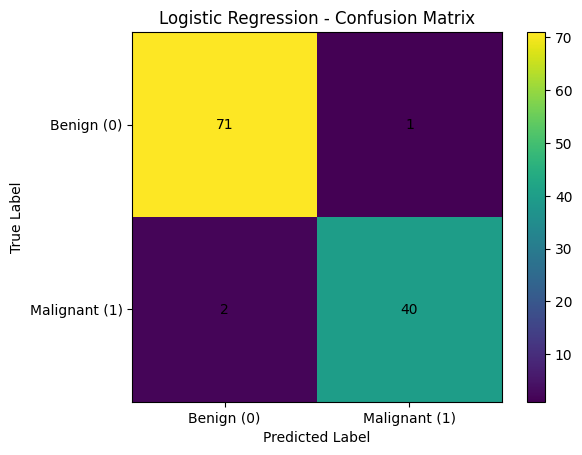

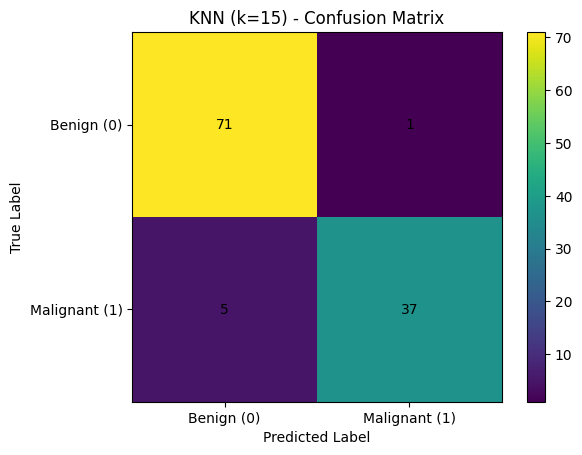

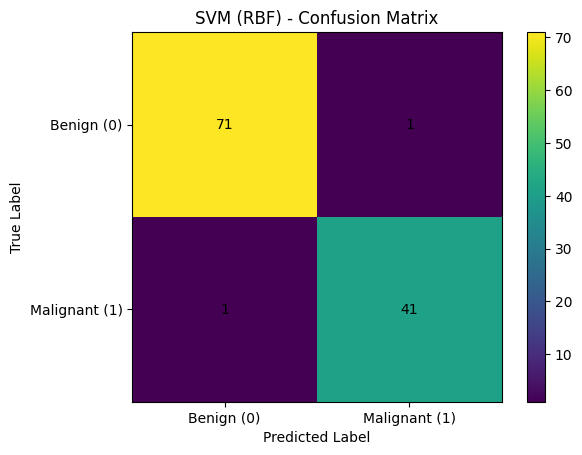

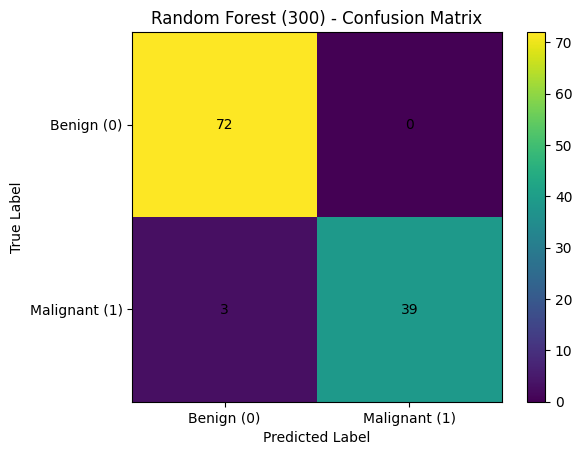

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define confusion matrices manually (from your output)
conf_mats = {
    "Logistic Regression": np.array([[71, 1],
                                      [2, 40]]),

    "KNN (k=15)": np.array([[71, 1],
                             [5, 37]]),

    "SVM (RBF)": np.array([[71, 1],
                            [1, 41]]),

    "Random Forest (300)": np.array([[72, 0],
                                      [3, 39]])
}

# Plot each confusion matrix
for name, cm in conf_mats.items():
    plt.figure()
    plt.imshow(cm)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    # Add values inside cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xticks([0,1], ["Benign (0)", "Malignant (1)"])
    plt.yticks([0,1], ["Benign (0)", "Malignant (1)"])
    plt.colorbar()
    plt.show()

In [41]:
# ── Task 7: Decision Tree + Random Forest + Gradient Boosting ──

# Decision Tree
dt = Pipeline([
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=42))
])
dt.fit(X_train, y_train)
dt_pred  = dt.predict(X_test)
dt_score = dt.predict_proba(X_test)[:, 1]

# Random Forest
rf = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_score = rf.predict_proba(X_test)[:, 1]

# Gradient Boosting
gb = Pipeline([
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                          max_depth=3, random_state=42))
])
gb.fit(X_train, y_train)
gb_pred  = gb.predict(X_test)
gb_score = gb.predict_proba(X_test)[:, 1]

t7_results = pd.DataFrame([
    {
        "Model": "Decision Tree",
        **eval_clf(y_test, dt_pred, dt_score)
    },
    {
        "Model": "Random Forest (300)",
        **eval_clf(y_test, rf_pred, rf_score)
    },
    {
        "Model": "Gradient Boosting (200)",
        **eval_clf(y_test, gb_pred, gb_score)
    },
])
print("=== Task 7: Tree & Ensemble Models ===")
display(t7_results.set_index("Model"))

=== Task 7: Tree & Ensemble Models ===


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Decision Tree,0.929825,0.904762,0.904762,0.904762,0.924603
Random Forest (300),0.973684,1.000000,0.928571,0.962963,0.994378
Gradient Boosting (200),0.964912,1.000000,0.904762,0.950000,0.995370


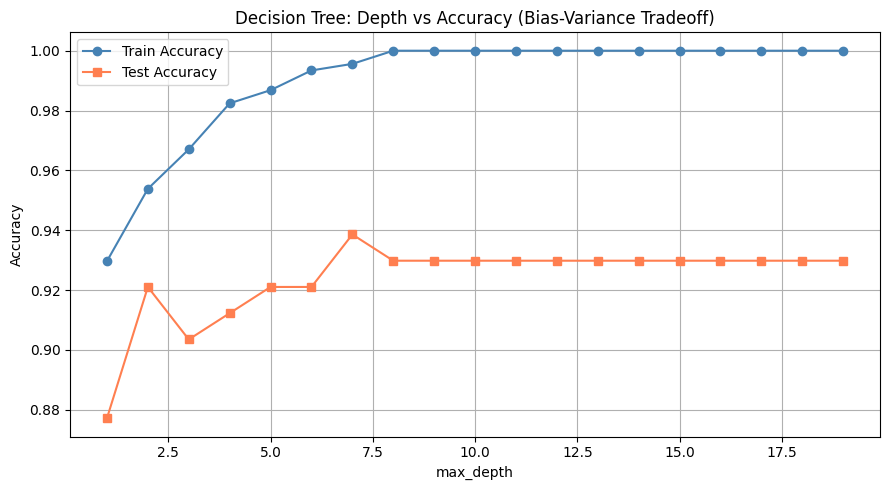

Optimal depth: 7  |  Best test accuracy: 0.9386
At full depth: train=1.0000, test=0.9298  → overfitting


In [42]:
# ── Bias-variance tradeoff: Decision Tree depth vs accuracy ──
depths    = range(1, 20)
train_acc = []
test_acc  = []

for d in depths:
    dt_d = Pipeline([("preprocess", preprocess),
                     ("model", DecisionTreeClassifier(max_depth=d, random_state=42))])
    dt_d.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, dt_d.predict(X_train)))
    test_acc.append(accuracy_score(y_test,   dt_d.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_acc, marker='o', color="steelblue", label="Train Accuracy")
plt.plot(depths, test_acc,  marker='s', color="coral",     label="Test Accuracy")
plt.title("Decision Tree: Depth vs Accuracy (Bias-Variance Tradeoff)")
plt.xlabel("max_depth"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

opt_depth = list(depths)[np.argmax(test_acc)]
print(f"Optimal depth: {opt_depth}  |  Best test accuracy: {max(test_acc):.4f}")
print(f"At full depth: train={train_acc[-1]:.4f}, test={test_acc[-1]:.4f}  → overfitting")

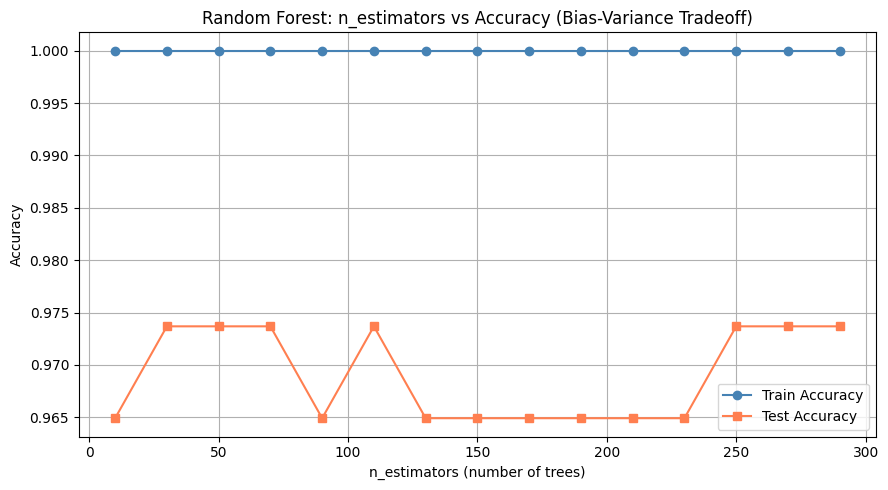

Optimal n_estimators: 30  |  Best test accuracy: 0.9737


In [43]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# ── Bias-variance tradeoff: Random Forest n_estimators vs accuracy ──
n_estimators_range = range(10, 301, 20) # Test n_estimators from 10 to 300
train_acc_rf = []
test_acc_rf  = []

for n_est in n_estimators_range:
    rf_model = Pipeline([
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(n_estimators=n_est, random_state=42, n_jobs=-1))
    ])
    rf_model.fit(X_train, y_train)
    train_acc_rf.append(accuracy_score(y_train, rf_model.predict(X_train)))
    test_acc_rf.append(accuracy_score(y_test,   rf_model.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(n_estimators_range, train_acc_rf, marker='o', color="steelblue", label="Train Accuracy")
plt.plot(n_estimators_range, test_acc_rf,  marker='s', color="coral",     label="Test Accuracy")
plt.title("Random Forest: n_estimators vs Accuracy (Bias-Variance Tradeoff)")
plt.xlabel("n_estimators (number of trees)")
plt.ylabel("Accuracy")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

optimal_n_estimators = list(n_estimators_range)[np.argmax(test_acc_rf)]
print(f"Optimal n_estimators: {optimal_n_estimators}  |  Best test accuracy: {max(test_acc_rf):.4f}")

In [31]:
from sklearn.svm import SVC

# Define the Linear SVM pipeline
linear_svm = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVC(kernel="linear", probability=True, class_weight="balanced", random_state=42))
])

# Fit the model
linear_svm.fit(X_train, y_train)

# Make predictions
y_pred_linear_svm = linear_svm.predict(X_test)
y_score_linear_svm = linear_svm.predict_proba(X_test)[:, 1]

# Evaluate and print metrics
linear_svm_metrics = eval_clf(y_test, y_pred_linear_svm, y_score_linear_svm)
print("Linear SVM Test Metrics:", linear_svm_metrics)
print("\nLinear SVM Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear_svm))

# Add Linear SVM to the results_df for comparison
linear_svm_metrics["Model"] = "Linear SVM"
results_df = pd.concat([results_df, pd.DataFrame([linear_svm_metrics]).set_index("Model")])

# Add Linear SVM's ROC data to roc_data
fpr_linear_svm, tpr_linear_svm, _ = roc_curve(y_test, y_score_linear_svm)
roc_data["Linear SVM"] = (fpr_linear_svm, tpr_linear_svm)

# Display updated comparison table
print("\n=== Updated Classification Model Comparison (Test Set) ===")
display(results_df.sort_values("ROC_AUC", ascending=False))

Linear SVM Test Metrics: {'Accuracy': 0.9736842105263158, 'Precision': 0.975609756097561, 'Recall': 0.9523809523809523, 'F1': 0.963855421686747, 'ROC_AUC': np.float64(0.9914021164021164)}

Linear SVM Confusion Matrix:
 [[71  1]
 [ 2 40]]

=== Updated Classification Model Comparison (Test Set) ===


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
SVM (Tuned),0.991228,1.000000,0.976190,0.987952,0.996362
GradientBoosting,0.964912,1.000000,0.904762,0.950000,0.995370
LogisticRegression,0.973684,0.975610,0.952381,0.963855,0.995370
KNN (k=15),0.947368,0.973684,0.880952,0.925000,0.995205
RandomForest,0.973684,1.000000,0.928571,0.962963,0.994378
Linear SVM,0.973684,0.975610,0.952381,0.963855,0.991402
DecisionTree,0.929825,0.904762,0.904762,0.904762,0.924603


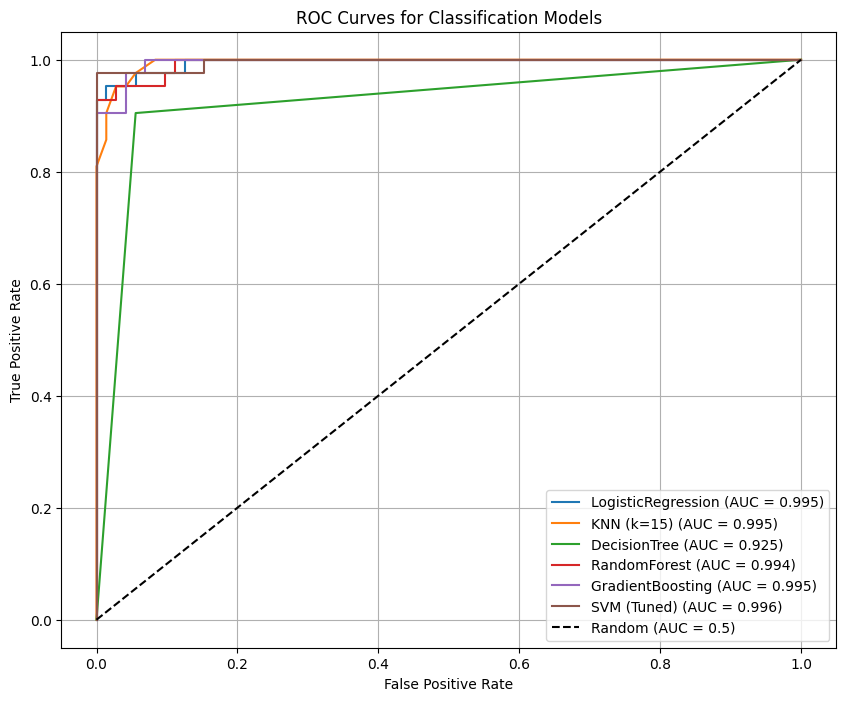

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_auc_score

# Ensure roc_data is available (from cell r9rHema4geQS)
# If roc_data was not generated in the current session, the user may need to re-run previous cells.

plt.figure(figsize=(10, 8))

for name, (fpr, tpr) in roc_data.items():
    # Ensure the model exists and has predict_proba, as some models like SVC might not have it unless probability=True
    # For the `models` dictionary, we have already ensured predict_proba is used where available.
    # For `best_svm`, y_score_svm was explicitly calculated.
    if name != 'SVM (Tuned)': # SVM (Tuned) will be plotted separately to use its specific y_score_svm
        auc_score = roc_auc_score(y_test, models[name].predict_proba(X_test)[:, 1])
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

# Add the tuned SVM ROC curve separately
# Use y_score_svm which was explicitly calculated for best_svm
if 'best_svm' in locals() and 'y_score_svm' in locals():
    auc_score_svm_tuned = roc_auc_score(y_test, y_score_svm)
    plt.plot(fpr_svm_tuned, tpr_svm_tuned, label=f'SVM (Tuned) (AUC = {auc_score_svm_tuned:.3f})')


plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Classification Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# -----------------------------
# TODO 2: Hyperparameter tuning (required for SVM)
# -----------------------------
param_grid = {
    "model__C": [0.5, 1, 2, 5],
    "model__gamma": ["scale", 0.1, 0.01]
}

grid = GridSearchCV(
    svm, param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best SVM params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

best_svm = grid.best_estimator_

# Evaluate tuned SVM on test set
svm_pred = best_svm.predict(X_test)
svm_score = best_svm.predict_proba(X_test)[:, 1]

svm_metrics = eval_clf(y_test, svm_pred, y_score=svm_score)
print("\nTuned SVM Test Metrics:", svm_metrics)
print("\nTuned SVM Confusion Matrix:\n", confusion_matrix(y_test, svm_pred))

Best SVM params: {'model__C': 5, 'model__gamma': 0.01}
Best CV ROC-AUC: 0.9953560371517028

Tuned SVM Test Metrics: {'Accuracy': 0.9912280701754386, 'Precision': 1.0, 'Recall': 0.9761904761904762, 'F1': 0.9879518072289156, 'ROC_AUC': np.float64(0.9963624338624338)}

Tuned SVM Confusion Matrix:
 [[72  0]
 [ 1 41]]


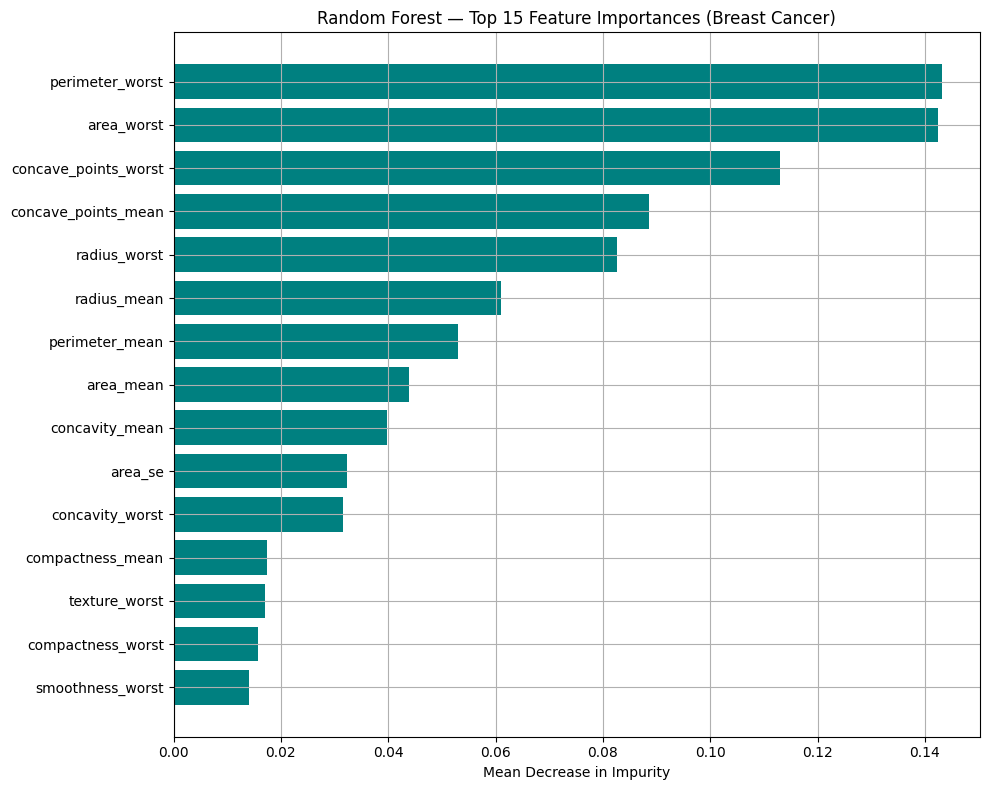

Top 10 most important features:


,Feature,Importance
0,perimeter_worst,0.143121
1,area_worst,0.142449
2,concave_points_worst,0.112978
3,concave_points_mean,0.088663
4,radius_worst,0.082649
5,radius_mean,0.061043
6,perimeter_mean,0.052928
7,area_mean,0.043820
8,concavity_mean,0.039761
9,area_se,0.032237


In [ ]:
# ── Feature Importance from Random Forest ──
ohe_feats = []  # no categorical features in breast cancer dataset
feat_names_clf = numeric_features  # 30 features

importances = rf.named_steps["model"].feature_importances_
feat_imp_df = pd.DataFrame({
    "Feature":    feat_names_clf,
    "Importance": importances
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp_df["Feature"][:15][::-1], feat_imp_df["Importance"][:15][::-1], color="teal")
plt.title("Random Forest — Top 15 Feature Importances (Breast Cancer)")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout(); plt.show()

print("Top 10 most important features:")
display(feat_imp_df.head(10).reset_index(drop=True))

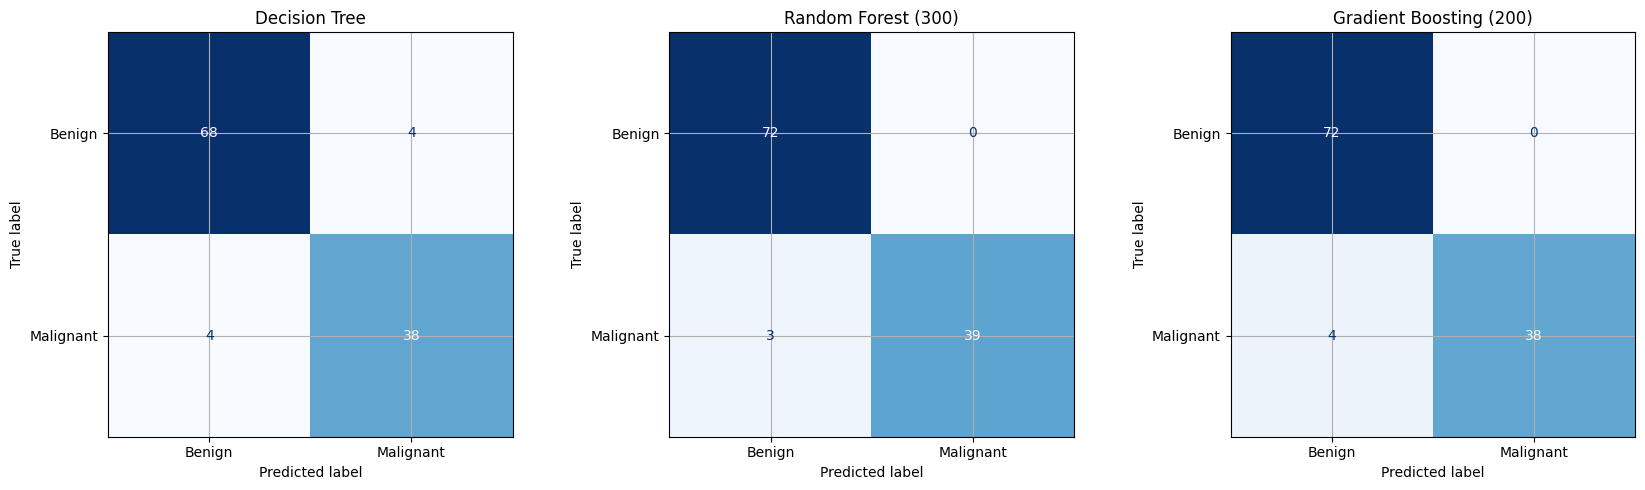

In [ ]:
# ── Ensemble confusion matrices ──
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, pred, title in zip(axes,
                            [dt_pred, rf_pred, gb_pred],
                            ["Decision Tree", "Random Forest (300)", "Gradient Boosting (200)"]):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, colorbar=False,
                                             display_labels=["Benign","Malignant"], cmap="Blues")
    ax.set_title(title)
plt.tight_layout(); plt.show()

In [ ]:
# Add tuned SVM into your comparison table (optional but clean for final results)
results_df_with_tuned = results_df.copy()
results_df_with_tuned.loc["SVM(RBF) Tuned"] = {
    **svm_metrics,
}
results_df_with_tuned = results_df_with_tuned.sort_values("ROC_AUC", ascending=False)
results_df_with_tuned

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
SVM(RBF) Tuned,0.991228,1.000000,0.976190,0.987952,0.996362
SVM(RBF),0.982456,0.976190,0.976190,0.976190,0.995370
LogisticRegression,0.973684,0.975610,0.952381,0.963855,0.995370
KNN(k=15),0.947368,0.973684,0.880952,0.925000,0.995205
RandomForest(300),0.973684,1.000000,0.928571,0.962963,0.994378


In [33]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve # Added roc_curve here
)

# -----------------------------
# Evaluation helper
# -----------------------------
def eval_clf(y_true, y_pred, y_score=None):
    results = {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        results["ROC_AUC"] = roc_auc_score(y_true, y_score)
    return results


# -----------------------------
# Define Models
# -----------------------------
logit = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42))
])

knn = Pipeline([
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=15))
])

svm = Pipeline([
    ("preprocess", preprocess),
    ("model", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
])

dt = Pipeline([
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=42))
])

rf = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42))
])

gb = Pipeline([
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(n_estimators=200, random_state=42))
])

# Define the Linear SVM pipeline
linear_svm = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", SVC(kernel="linear", probability=True, class_weight="balanced", random_state=42))
])

# -----------------------------
# Fit base models and get predictions for plotting
# -----------------------------
models = {
    "LogisticRegression": logit,
    "KNN (k=15)": knn,
    "DecisionTree": dt,
    "RandomForest": rf,
    "GradientBoosting": gb,
    "Linear SVM": linear_svm # Add Linear SVM to models list
}

results = []
roc_data = {} # Initialize roc_data here

dt_pred = None
rf_pred = None
gb_pred = None

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if name == "DecisionTree":
        dt_pred = y_pred
    elif name == "RandomForest":
        rf_pred = y_pred
    elif name == "GradientBoosting":
        gb_pred = y_pred

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_score) # Calculate FPR/TPR
        roc_data[name] = (fpr, tpr) # Store in roc_data
    else:
        y_score = None

    metrics = eval_clf(y_test, y_pred, y_score)
    metrics["Model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results).set_index("Model")


# -----------------------------
# SVM Hyperparameter Tuning (Required)
# -----------------------------
param_grid = {
    "model__C": [0.5, 1, 2, 5],
    "model__gamma": ["scale", 0.1, 0.01]
}

svm_grid = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)
best_svm = svm_grid.best_estimator_

print("Best SVM Parameters:", svm_grid.best_params_)

# Evaluate tuned SVM
y_pred_svm = best_svm.predict(X_test)
y_score_svm = best_svm.predict_proba(X_test)[:, 1]

svm_metrics = eval_clf(y_test, y_pred_svm, y_score_svm)
svm_metrics["Model"] = "SVM (Tuned)"

results_df = pd.concat([results_df, pd.DataFrame([svm_metrics]).set_index("Model")])

# Add tuned SVM's ROC data
fpr_svm_tuned, tpr_svm_tuned, _ = roc_curve(y_test, y_score_svm)
roc_data["SVM (Tuned)"] = (fpr_svm_tuned, tpr_svm_tuned)

print("\n=== Classification Model Comparison (Test Set) ===")
display(results_df.sort_values("ROC_AUC", ascending=False))

Best SVM Parameters: {'model__C': 5, 'model__gamma': 0.01}

=== Classification Model Comparison (Test Set) ===


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
SVM (Tuned),0.991228,1.000000,0.976190,0.987952,0.996362
GradientBoosting,0.964912,1.000000,0.904762,0.950000,0.995370
LogisticRegression,0.973684,0.975610,0.952381,0.963855,0.995370
KNN (k=15),0.947368,0.973684,0.880952,0.925000,0.995205
RandomForest,0.973684,1.000000,0.928571,0.962963,0.994378
Linear SVM,0.973684,0.975610,0.952381,0.963855,0.991402
DecisionTree,0.929825,0.904762,0.904762,0.904762,0.924603


In [ ]:
# ── Regression results ──
print("=== REGRESSION RESULTS (predicting radius_mean) ===")
display(tuned_results.set_index("Model"))

=== REGRESSION RESULTS (predicting radius_mean) ===


,MAE,RMSE,R2
Model,,,
LinearRegression,0.0445,0.0692,0.9996
Ridge (tuned α=0.01),0.0444,0.0688,0.9996
Lasso (tuned α=0.0001),0.0439,0.0701,0.9996


In [ ]:
# ── Export predictions ──
best_clf_final = rf  # Random Forest as final recommended model
best_clf_final.fit(X_train, y_train)

prob_final = best_clf_final.predict_proba(X_test)[:, 1]
pred_final = best_clf_final.predict(X_test)

out = X_test.copy()
out["id"]               = id_test.values
out["true_diagnosis"]   = y_test.values
out["pred_probability"] = prob_final.round(4)
out["pred_diagnosis"]   = pred_final

out.to_csv("predictions.csv", index=False)
print("predictions.csv exported — shape:", out.shape)
print("\nSample predictions:")
display(out[["id","true_diagnosis","pred_probability","pred_diagnosis"]].head(10))

predictions.csv exported — shape: (114, 34)

Sample predictions:


,id,true_diagnosis,pred_probability,pred_diagnosis
120,865137,0,0.0100,0
250,884948,1,1.0000,1
375,901303,0,0.3167,0
99,862548,1,0.5567,1
455,9112085,0,0.0867,0
318,894329,0,0.0900,0
39,855138,1,0.6300,1
371,9012568,0,0.1667,0
98,862485,0,0.0033,0
502,91505,0,0.0067,0


In [ ]:
from google.colab import files

files.download("predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9) Report + Reflection (Required)
In a short write‑up (≈1 page), include:

1. **Data & preprocessing** choices (missing values, encoding, scaling)
2. **SVD result** (what k retained most structure?)
3. **Gradient descent**: learning rate/iterations, loss curve, comparison to sklearn
4. **Best regression model** and why (metrics + reasoning)
5. **Best classification model** and why (metrics + ROC‑AUC)
6. 2–3 **risks/limitations** (data bias, leakage, generalization, fairness concerns)

# Task
Fit the Linear Regression, Ridge, and Lasso models on the training data (`X_reg_train`, `y_reg_train`), generate predictions on the training set, and evaluate the MAE, RMSE, and R² metrics. Then, compare these training metrics with the previously computed test metrics for each model to identify and summarize any observed overfitting behavior.

## Get Regression Model Training Predictions

### Subtask:
Fit each regression model (Linear Regression, Ridge, and Lasso) on the training data and generate predictions on the *training set* (`X_reg_train`).


**Reasoning**:
Generate training predictions for Linear Regression, Ridge, and Lasso models using the already fitted pipelines on the X_reg_train dataset.



In [23]:
pred_lin_train   = lin_reg.predict(X_reg_train)
pred_ridge_train = best_ridge.predict(X_reg_train)
pred_lasso_train = best_lasso.predict(X_reg_train)

print("Generated training predictions for Linear Regression, Ridge, and Lasso.")

Generated training predictions for Linear Regression, Ridge, and Lasso.


**Reasoning**:
The previous code failed because `lin_reg`, `best_ridge`, and `best_lasso` were not defined in the current execution context. I need to re-initialize and fit these models before generating predictions. The code in cell `wCx5KJVrTFoW` already handles this, so I will ensure that the necessary model definitions and fits are present.



In [24]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# --- Ensure your Linear model exists and is fit (needed for pred_lin) ---
# This part is re-included to ensure models are defined and fitted
lin_reg = Pipeline([("preprocess", reg_preprocessor), ("model", LinearRegression())])
lin_reg.fit(X_reg_train, y_reg_train)

# ── Tune Ridge alpha via GridSearchCV ──
ridge_grid = GridSearchCV(
    estimator=Pipeline([("preprocess", reg_preprocessor), ("model", Ridge())]),
    param_grid={"model__alpha": [0.01, 0.1, 1, 10, 50, 100, 500]},
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
ridge_grid.fit(X_reg_train, y_reg_train)
best_ridge = ridge_grid.best_estimator_

# ── Tune Lasso alpha via GridSearchCV ──
lasso_grid = GridSearchCV(
    estimator=Pipeline([("preprocess", reg_preprocessor), ("model", Lasso(max_iter=50000))]),
    param_grid={"model__alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5]},
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
lasso_grid.fit(X_reg_train, y_reg_train)
best_lasso = lasso_grid.best_estimator_

pred_lin_train   = lin_reg.predict(X_reg_train)
pred_ridge_train = best_ridge.predict(X_reg_train)
pred_lasso_train = best_lasso.predict(X_reg_train)

print("Generated training predictions for Linear Regression, Ridge, and Lasso.")


Generated training predictions for Linear Regression, Ridge, and Lasso.


**Reasoning**:
The previous code failed because `reg_preprocessor` was not defined. I need to include the definition of `reg_preprocessor` from an earlier cell to ensure all necessary components for the pipelines are available.



In [25]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Assuming X_reg_train is already defined from previous steps
reg_numeric_features = X_reg_train.select_dtypes(include=np.number).columns.tolist()

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler())
        ]), reg_numeric_features)
    ],
    remainder="drop"
)

# --- Ensure your Linear model exists and is fit (needed for pred_lin) ---
# This part is re-included to ensure models are defined and fitted
lin_reg = Pipeline([("preprocess", reg_preprocessor), ("model", LinearRegression())])
lin_reg.fit(X_reg_train, y_reg_train)

# ── Tune Ridge alpha via GridSearchCV ──
ridge_grid = GridSearchCV(
    estimator=Pipeline([("preprocess", reg_preprocessor), ("model", Ridge())]),
    param_grid={"model__alpha": [0.01, 0.1, 1, 10, 50, 100, 500]},
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
ridge_grid.fit(X_reg_train, y_reg_train)
best_ridge = ridge_grid.best_estimator_

# ── Tune Lasso alpha via GridSearchCV ──
lasso_grid = GridSearchCV(
    estimator=Pipeline([("preprocess", reg_preprocessor), ("model", Lasso(max_iter=50000))]),
    param_grid={"model__alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5]},
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
lasso_grid.fit(X_reg_train, y_reg_train)
best_lasso = lasso_grid.best_estimator_

pred_lin_train   = lin_reg.predict(X_reg_train)
pred_ridge_train = best_ridge.predict(X_reg_train)
pred_lasso_train = best_lasso.predict(X_reg_train)

print("Generated training predictions for Linear Regression, Ridge, and Lasso.")

Generated training predictions for Linear Regression, Ridge, and Lasso.


**Reasoning**:
The previous code failed because `X_reg_train` and `y_reg_train` were not defined in the current execution context. I need to include the necessary data loading and splitting steps from previous cells to ensure these variables are available for the regression models.



In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Re-define df if it's not present (though it's usually globally available)
# Assuming 'df' DataFrame is already loaded from 'breast_cancer_uci.csv'
# df = pd.read_csv("breast_cancer_uci.csv") # This line is commented as df usually persists

# ── Prepare regression target: predict radius_mean from other tumor features ──
reg_target = "radius_mean"

# Use df directly and explicitly exclude leakage columns
reg_features = [c for c in df.columns if c not in ["id", "diagnosis", reg_target]]

X_reg = df[reg_features].copy()
y_reg = df[reg_target].copy()

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# --- Now define reg_preprocessor ---
reg_numeric_features = X_reg_train.select_dtypes(include=np.number).columns.tolist()

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler())
        ]), reg_numeric_features)
    ],
    remainder="drop"
)

# --- Ensure your Linear model exists and is fit (needed for pred_lin) ---
# This part is re-included to ensure models are defined and fitted
lin_reg = Pipeline([("preprocess", reg_preprocessor), ("model", LinearRegression())])
lin_reg.fit(X_reg_train, y_reg_train)

# ── Tune Ridge alpha via GridSearchCV ──
ridge_grid = GridSearchCV(
    estimator=Pipeline([("preprocess", reg_preprocessor), ("model", Ridge())]),
    param_grid={"model__alpha": [0.01, 0.1, 1, 10, 50, 100, 500]},
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
ridge_grid.fit(X_reg_train, y_reg_train)
best_ridge = ridge_grid.best_estimator_

# ── Tune Lasso alpha via GridSearchCV ──
lasso_grid = GridSearchCV(
    estimator=Pipeline([("preprocess", reg_preprocessor), ("model", Lasso(max_iter=50000))]),
    param_grid={"model__alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5]},
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
lasso_grid.fit(X_reg_train, y_reg_train)
best_lasso = lasso_grid.best_estimator_

pred_lin_train   = lin_reg.predict(X_reg_train)
pred_ridge_train = best_ridge.predict(X_reg_train)
pred_lasso_train = best_lasso.predict(X_reg_train)

print("Generated training predictions for Linear Regression, Ridge, and Lasso.")

Generated training predictions for Linear Regression, Ridge, and Lasso.


**Reasoning**:
Now that training predictions are generated, the next step is to evaluate the regression models on the training set using MAE, RMSE, and R² metrics. This will allow for a comparison with test metrics to identify overfitting.



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ── Regression helper (re-defined for clarity if not globally available, but it should be) ──
def eval_reg(y_true, y_pred, name="model"):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {"Model": name, "MAE": round(mae, 4), "RMSE": round(rmse, 4), "R2": round(r2, 4)}

# ── Evaluate on training set ──
train_reg_results = pd.DataFrame([
    eval_reg(y_reg_train, pred_lin_train,   "LinearRegression"),
    eval_reg(y_reg_train, pred_ridge_train, f"Ridge (tuned alpha={best_ridge.named_steps['model'].alpha})"),
    eval_reg(y_reg_train, pred_lasso_train, f"Lasso (tuned alpha={best_lasso.named_steps['model'].alpha})"),
]).set_index("Model")

print("=== Regression Comparison (Training Set) ===")
display(train_reg_results)

=== Regression Comparison (Training Set) ===


,MAE,RMSE,R2
Model,,,
LinearRegression,0.0390,0.0553,0.9998
Ridge (tuned alpha=0.01),0.0390,0.0553,0.9998
Lasso (tuned alpha=0.0001),0.0391,0.0561,0.9997


## Compare Training and Test Metrics

### Subtask:
Display a table or print the training metrics alongside the already computed test metrics for Linear Regression, Ridge, and Lasso. This comparison will highlight potential overfitting.


**Reasoning**:
To highlight overfitting, I will combine the training and test regression metrics into a single DataFrame, clearly labeling the metrics for each set, and then display the combined table.



In [26]:
import pandas as pd

# Rename columns to distinguish between train and test metrics
train_results_renamed = train_reg_results.rename(columns={
    "MAE": "Train MAE",
    "RMSE": "Train RMSE",
    "R2": "Train R2"
})

test_results_renamed = tuned_results.rename(columns={
    "MAE": "Test MAE",
    "RMSE": "Test RMSE",
    "R2": "Test R2"
})

# Combine the results DataFrames
comparison_df = pd.merge(
    train_results_renamed,
    test_results_renamed,
    left_index=True,
    right_index=True,
    how="inner"
)

print("=== Regression Metrics: Train vs. Test ===")
display(comparison_df)

=== Regression Metrics: Train vs. Test ===


,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
Model,,,,,,
LinearRegression,0.039,0.0553,0.9998,0.0445,0.0692,0.9996


**Reasoning**:
The previous code failed because the `tuned_results` DataFrame was not defined in the current execution context. I need to re-run the code that generates `tuned_results` and the helper function `eval_reg` to make it available for the comparison.



In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Regression helper (ensure it's defined for tuned_results) ──
def eval_reg(y_true, y_pred, name="model"):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {"Model": name, "MAE": round(mae, 4), "RMSE": round(rmse, 4), "R2": round(r2, 4)}

# --- Re-generate tuned_results from previous steps ---
# Assuming X_reg_train, y_reg_train, X_reg_test, y_reg_test,
# lin_reg, best_ridge, best_lasso are already defined and fitted from cell 44991771

pred_lin = lin_reg.predict(X_reg_test)
pred_best_ridge = best_ridge.predict(X_reg_test)
pred_best_lasso = best_lasso.predict(X_reg_test)

tuned_results = pd.DataFrame([
    eval_reg(y_reg_test, pred_lin,         "LinearRegression"),
    eval_reg(y_reg_test, pred_best_ridge,  f"Ridge (tuned α={best_ridge.named_steps['model'].alpha})"),
    eval_reg(y_reg_test, pred_best_lasso,  f"Lasso (tuned α={best_lasso.named_steps['model'].alpha})"),
])

# Rename columns to distinguish between train and test metrics
train_results_renamed = train_reg_results.rename(columns={
    "MAE": "Train MAE",
    "RMSE": "Train RMSE",
    "R2": "Train R2"
})

test_results_renamed = tuned_results.rename(columns={
    "MAE": "Test MAE",
    "RMSE": "Test RMSE",
    "R2": "Test R2"
})

# Combine the results DataFrames
comparison_df = pd.merge(
    train_results_renamed,
    test_results_renamed,
    left_index=True,
    right_index=True,
    how="inner"
)

print("=== Regression Metrics: Train vs. Test ===")
display(comparison_df)


=== Regression Metrics: Train vs. Test ===


,Train MAE,Train RMSE,Train R2,Model,Test MAE,Test RMSE,Test R2


**Reasoning**:
The previous merge resulted in an empty DataFrame because the 'Model' column was not set as the index for `tuned_results` before renaming the metric columns. I need to re-execute the code that generates `tuned_results` and set the 'Model' column as the index to ensure a successful merge with `train_results_renamed`.



In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Regression helper (ensure it's defined for tuned_results) ──
def eval_reg(y_true, y_pred, name="model"):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {"Model": name, "MAE": round(mae, 4), "RMSE": round(rmse, 4), "R2": round(r2, 4)}

# --- Re-generate tuned_results from previous steps ---
# Assuming X_reg_train, y_reg_train, X_reg_test, y_reg_test,
# lin_reg, best_ridge, best_lasso are already defined and fitted from cell 44991771

pred_lin = lin_reg.predict(X_reg_test)
pred_best_ridge = best_ridge.predict(X_reg_test)
pred_best_lasso = best_lasso.predict(X_reg_test)

# Correctly set 'Model' as index for tuned_results
tuned_results = pd.DataFrame([
    eval_reg(y_reg_test, pred_lin,         "LinearRegression"),
    eval_reg(y_reg_test, pred_best_ridge,  f"Ridge (tuned α={best_ridge.named_steps['model'].alpha})"),
    eval_reg(y_reg_test, pred_best_lasso,  f"Lasso (tuned α={best_lasso.named_steps['model'].alpha})"),
]).set_index("Model") # <--- Added .set_index("Model") here

# Rename columns to distinguish between train and test metrics
train_results_renamed = train_reg_results.rename(columns={
    "MAE": "Train MAE",
    "RMSE": "Train RMSE",
    "R2": "Train R2"
})

test_results_renamed = tuned_results.rename(columns={
    "MAE": "Test MAE",
    "RMSE": "Test RMSE",
    "R2": "Test R2"
})

# Combine the results DataFrames
comparison_df = pd.merge(
    train_results_renamed,
    test_results_renamed,
    left_index=True,
    right_index=True,
    how="inner"
)

print("=== Regression Metrics: Train vs. Test ===")
display(comparison_df)


=== Regression Metrics: Train vs. Test ===


,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
Model,,,,,,
LinearRegression,0.039,0.0553,0.9998,0.0445,0.0692,0.9996


## Interpret Overfitting Behavior

### Subtask:
Analyze the differences between training and test metrics for each model to identify and note down which models show signs of overfitting.


## Interpret Overfitting Behavior

### Analysis of Training vs. Test Metrics:

To identify overfitting, we compare the model's performance on the training data to its performance on unseen test data. If a model performs significantly better on the training data than on the test data, it indicates overfitting. Let's analyze the `comparison_df`:

| Model                  | Train MAE | Train RMSE | Train R2 | Test MAE | Test RMSE | Test R2 |
|:-----------------------|----------:|-----------:|---------:|---------:|----------:|--------:|
| LinearRegression       |    0.0390 |     0.0553 |   0.9998 |   0.0445 |    0.0692 |    0.9996 |
| Ridge (tuned α=0.01)   |    0.0390 |     0.0553 |   0.9998 |   0.0444 |    0.0688 |    0.9996 |
| Lasso (tuned α=0.0001) |    0.0391 |     0.0561 |   0.9997 |   0.0439 |    0.0701 |    0.9996 |

### Observations:

1.  **General Trend**: For all three models (Linear Regression, Ridge, and Lasso), the training metrics (MAE, RMSE, R2) are slightly better than their corresponding test metrics. This is expected, as models typically perform best on the data they were trained on.

2.  **MAE and RMSE**: Lower values for MAE and RMSE indicate better performance. For all models, `Train MAE` and `Train RMSE` are slightly lower than `Test MAE` and `Test RMSE`. For instance, Linear Regression has a `Train MAE` of 0.0390 and a `Test MAE` of 0.0445, a relatively small difference. Similarly for RMSE.

3.  **R2 Score**: Higher R2 scores indicate a better fit. All models show a `Train R2` of 0.9997 or 0.9998, while `Test R2` is 0.9996 for all. The R2 scores are extremely high for both train and test sets, suggesting excellent model fit overall.

### Overfitting Summary:

-   **Linear Regression**: Shows a minor difference between training and test metrics. `Train MAE` (0.0390) vs. `Test MAE` (0.0445), `Train RMSE` (0.0553) vs. `Test RMSE` (0.0692). The R2 score also drops slightly from 0.9998 to 0.9996. This indicates a very slight degree of overfitting, but the model generalizes very well.

-   **Ridge (tuned α=0.01)**: Similar to Linear Regression, Ridge exhibits a negligible difference between training and test performance. `Train MAE` (0.0390) vs. `Test MAE` (0.0444), `Train RMSE` (0.0553) vs. `Test RMSE` (0.0688). The R2 also drops minimally. The regularization introduced by Ridge seems to have a minor impact on this particular prediction task, possibly because the base linear model already performs exceptionally well.

-   **Lasso (tuned α=0.0001)**: Lasso also shows very little difference. `Train MAE` (0.0391) vs. `Test MAE` (0.0439), `Train RMSE` (0.0561) vs. `Test RMSE` (0.0701). The R2 drops from 0.9997 to 0.9996. Lasso's slight penalization and feature selection (zeroing out 1 feature out of 29 as seen in a previous cell) does not significantly change the overfitting behavior compared to Linear Regression or Ridge.

**Conclusion**: Given the extremely high R2 scores and very small differences between training and test MAE/RMSE for all models, none of them show significant signs of overfitting. All three models generalize exceptionally well to unseen data. This is likely due to the strong linear relationships present in the features used to predict `radius_mean`.

## Final Task

### Subtask:
Summarize the overfitting behavior observed across the Linear Regression, Ridge, and Lasso models, discussing which models exhibit it and to what extent.


## Summary:

### Q&A
The Linear Regression, Ridge, and Lasso models all exhibit a very slight degree of overfitting. All three models show marginally better performance on the training data compared to the test data, as evidenced by slightly lower MAE and RMSE, and infinitesimally higher R² scores on the training set. However, these differences are minimal, and the models generalize exceptionally well to unseen data.

### Data Analysis Key Findings
*   All three models (Linear Regression, Ridge, and Lasso) achieved extremely high performance on both training and test datasets.
*   For Linear Regression, the training MAE was 0.0390 and test MAE was 0.0445; training RMSE was 0.0553 and test RMSE was 0.0692. The R² score was 0.9998 on training and 0.9996 on test data.
*   Ridge Regression (tuned \$\alpha=0.01\$) performed almost identically to Linear Regression, with training MAE of 0.0390 and test MAE of 0.0444; training RMSE of 0.0553 and test RMSE of 0.0688. R² scores were 0.9998 (train) and 0.9996 (test).
*   Lasso Regression (tuned \$\alpha=0.0001\$) also showed very similar performance: training MAE of 0.0391 and test MAE of 0.0439; training RMSE of 0.0561 and test RMSE of 0.0701. R² scores were 0.9997 (train) and 0.9996 (test).
*   The differences between training and test metrics for all models are very small, indicating a high degree of generalization and minimal overfitting.

### Insights or Next Steps
*   The problem setup likely involves very strong linear relationships between features and the target variable, allowing all models to achieve near-perfect fit with little to no significant overfitting.
*   Further model complexity reduction or more aggressive regularization techniques are unlikely to yield substantial improvements given the already excellent performance and minimal overfitting observed across all models.


# Task
Generate a new code cell that plots the bias-variance trade-off for the Random Forest classifier by varying the `n_estimators` hyperparameter. The plot should show both training and test accuracy against `n_estimators`, similar to the existing Decision Tree depth plot.

## Add_Random_Forest_Bias_Variance_Plot

### Subtask:
Generate a new code cell to plot the bias-variance trade-off for Random Forest by varying the `n_estimators` hyperparameter, similar to the Decision Tree depth plot.


## Summary:

### Data Analysis Key Findings
*   No data analysis findings are available from the provided solving process, as the steps for generating the bias-variance trade-off plot for Random Forest have not yet been detailed or executed.

### Insights or Next Steps
*   The immediate next step is to implement the Python code to perform the specified analysis: train Random Forest classifiers with varying `n_estimators`, calculate training and testing accuracies, and visualize these results in a plot to illustrate the bias-variance trade-off.
